## 3.9. 文本与标注

- 在进行数据可视化的时候，有的时候需要加以一些辅助说明信息。通过文本与标注可以更好的理解与分析可视化数据。常用的辅助方式包含：
    - 进行文字说明
    - 进行表格说明
    - 其他说明方式：图例、箭头等指示符号。

### (1) 文本标注-text/figtext函数

- text与figtext提供文本绘制，既可以作为可视化信息的一部分，也可以用来辅助可视化信息更加直观。
    - text在Axes对象内添加文本。
    - figtext在Figure对象内添加文本。
- Axes与Figure的区别在于：
    - 绘制的参照点不同（也是就是使用的坐标系不同），Axes中添加文本则受Axes的变化影响，Figure中添加文本则受Figure变化的影响。
    - text一般用于数据点注释，曲线标注等用途，figtext则用于水印、背景文字等添加绘制。
- 在前面我们应该体验到的一个常识，在这里专门强调：
    - Figure的坐标单位是`[0,1]`逻辑坐标单位，并通过figsize与dpi转换为像素单位

- 体验text与figtext的异同

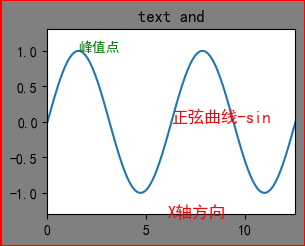

In [22]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建示例数据
x = np.linspace(0, np.pi * 4, 100)
y = np.sin(x)

plt.figure(figsize=(3.2, 2.4), facecolor="gray", edgecolor="red", frameon=True, linewidth=2)
# 绘制图形
plt.plot(x, y)
plt.title('text and')
plt.xlim(0, np.pi * 4)
plt.ylim(-1.3, 1.3)

# 使用 text() 添加注释
plt.text( np.pi * 2,  0, '正弦曲线-sin', fontsize=12, color='red')
plt.text(np.pi/2, np.sin(np.pi/2), '峰值点', fontsize=10, color='green')

plt.figtext(0.5, 0.1, 'X轴方向', fontsize=12, color='red')

plt.show()

- 代码说明：
    - `plt.text( np.pi * 2,  0, '正弦曲线-sin', fontsize=12, color='red')`在曲线中间位置绘制了文本。
    - `plt.text(np.pi/2, np.sin(np.pi/2), '峰值点', fontsize=10, color='green')`在90°位置绘制了文本。
        - 坐标系单位是坐标轴单位，坐标轴单位一般使用者通过Axes设置，设置方式有多种。
    - `plt.figtext(0.5, 0.01, 'X轴方向', fontsize=12, color='red')`在figure画布上绘制了文本
        - 坐标系单位是`[0, 1]`
    - 在代码中使用`%matplotlib qt`，以GUI方式运行，并拖动窗体感受两者的差异。

#### text函数

- text函数的原型定义与参数说明。

```python
matplotlib.pyplot.text(
    x, y,   # 绘制的坐标位置，参数类型float
    s,      # 绘制的文本内容，参数类型str。
    fontdict=None,  # 指定绘制文本的字体属性，参数类型是字典dict。该参数的字典方式不鼓励，而是采用`**fontdict`关键字参数方式。
    **kwargs)  # 设置来自Text对象的属性。
```

函数返回Text对象。

- x, y相关的参数说明
    - x, y指定文本绘制坐标比较容易理解，但是绘制的文本与这个坐标还有一个对齐方式的问题。
        - 水平方向：这个由`**kwargs`参数中Text对象的属性horizontalalignment来设置，该属性可以简写'ha'
            - 取值：{'left', 'center', 'right'}
        - 垂直方向：这个由`**kwargs`参数中Text对象的属性verticalalignment来设置，该属性可以简写'va'
            - 取值：{'baseline', 'bottom', 'center', 'center_baseline', 'top'}
    - x,y的对齐方式默认值：
        - horizontalalignment：left
        - verticalalignment：baseline

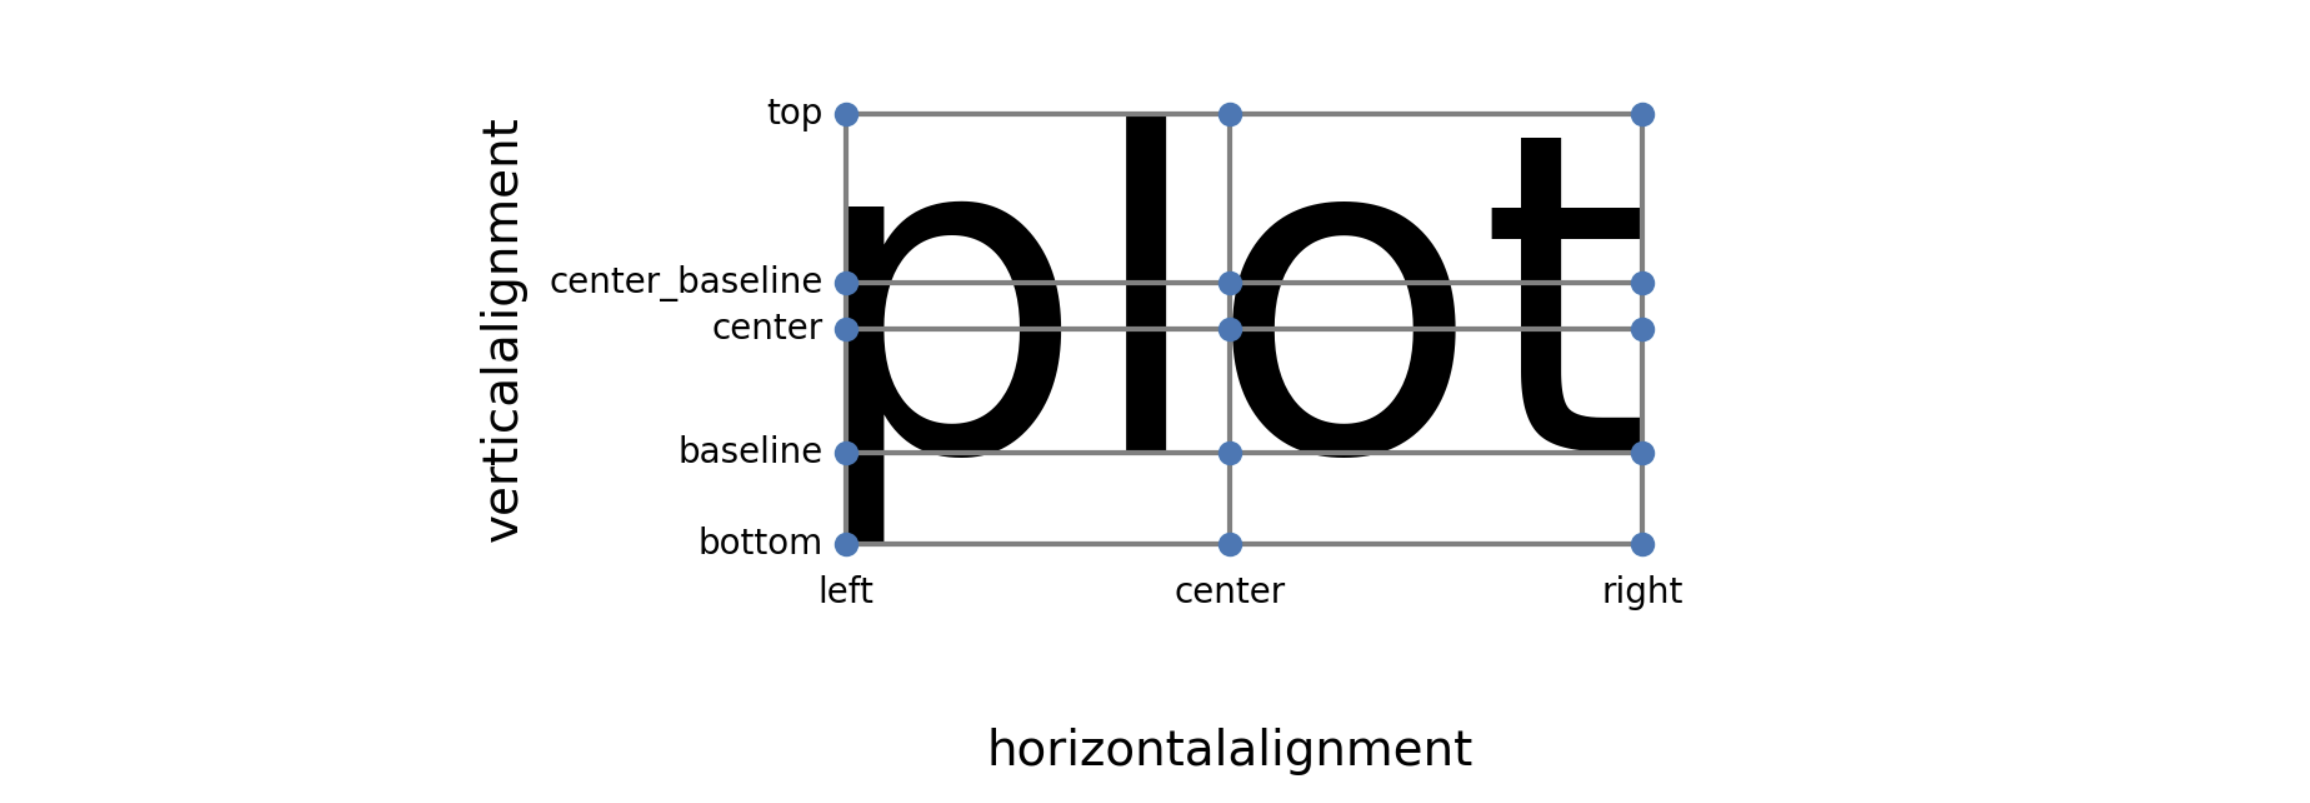

- x,y参数与对齐方式使用例子：

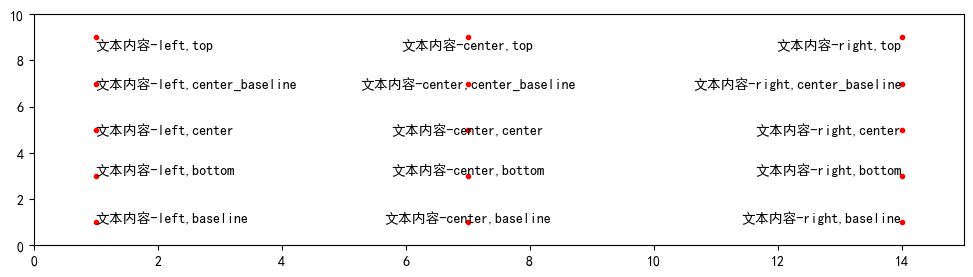

In [33]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建示例数据


plt.figure(figsize=(12, 3))
plt.xlim(0, 15)  # 设置坐标单位
plt.ylim(0, 10)  # 设置坐标单位
# horizontalalignment = left, verticalalignment={'baseline', 'bottom', 'center', 'center_baseline', 'top'}
plt.text(1, 1, "文本内容-left,baseline", horizontalalignment="left", verticalalignment="baseline")
plt.text(1, 3, "文本内容-left,bottom", horizontalalignment="left", verticalalignment="bottom")
plt.text(1, 5, "文本内容-left,center", horizontalalignment="left", verticalalignment="center")
plt.text(1, 7, "文本内容-left,center_baseline", horizontalalignment="left", verticalalignment="center_baseline")
plt.text(1, 9, "文本内容-left,top", horizontalalignment="left", verticalalignment="top")
plt.scatter((1, 1, 1, 1, 1), (1, 3, 5, 7, 9), marker=".", color="red")

# verticalalignment = center, verticalalignment={'baseline', 'bottom', 'center', 'center_baseline', 'top'}
plt.text(7, 1, "文本内容-center,baseline", horizontalalignment="center", verticalalignment="baseline")
plt.text(7, 3, "文本内容-center,bottom", horizontalalignment="center", verticalalignment="bottom")
plt.text(7, 5, "文本内容-center,center", horizontalalignment="center", verticalalignment="center")
plt.text(7, 7, "文本内容-center,center_baseline", horizontalalignment="center", verticalalignment="center_baseline")
plt.text(7, 9, "文本内容-center,top", horizontalalignment="center", verticalalignment="top")
plt.scatter((7, 7, 7, 7, 7), (1, 3, 5, 7, 9), marker=".", color="red")

# verticalalignment = right, verticalalignment={'baseline', 'bottom', 'center', 'center_baseline', 'top'}
plt.text(14, 1, "文本内容-right,baseline", horizontalalignment="right", verticalalignment="baseline")
plt.text(14, 3, "文本内容-right,bottom", horizontalalignment="right", verticalalignment="bottom")
plt.text(14, 5, "文本内容-right,center", horizontalalignment="right", verticalalignment="center")
plt.text(14, 7, "文本内容-right,center_baseline", horizontalalignment="right", verticalalignment="center_baseline")
plt.text(14, 9, "文本内容-right,top", ha="right", va="top")
plt.scatter((14, 14, 14, 14, 14), (1, 3, 5, 7, 9), marker=".", color="red")
plt.show()

- 代码说明：
    - `plt.text(14, 9, "文本内容-right,top", ha="right", va="top")`这行代码我们使用了简写属性。
    - `plt.scatter((14, 14, 14, 14, 14), (1, 3, 5, 7, 9), marker=".", color="red")`我们绘制了参考点，可以更好的理解ha与va参数的实际效果。
    - 我们大部分都是用va="baseline"缺省值就够用，在ha方面根据需要会调整使用"left","center","right"。

- fontdict可以设置的字体属性，（注意官方文档建议不使用字典类型的方式，而是使用关键字参数方式），如果该参数没有设置，会使用环境变量中的设置`rcParams`，在matplotlib中使用的字体属性来自`W3C Cascading Style Sheet, Level 1`(`https://www.w3.org/TR/1998/REC-CSS2-19980512/`)的6个属性
    - font-family'：字体名，比如： 'sans-serif', 'serif', 'cursive', 'fantasy', 'monospace'等。
        - 取值方式： `[ <family-name> | <generic-family> ] [, [<family-name> | <generic-family> ]]*`
        - family-name 可以使用get_font_names获取。
    - 'font-style'：字体样式，主要是斜体还是正体。
        - 取值方式：`all | [ normal | italic | oblique ] [, [normal | italic | oblique] ]*`
    - 'font-variant'：字体变体，这个对汉字没有意义，主要是西文中的大小写的变体选择。比如small-caps表示小型大写字母。
        - 取值方式：`[normal | small-caps] [,[normal | small-caps]]*`
    - 'font-weight'：字体权重，决定字体的粗细。
        - 取值方式：`all | [normal | bold | 100 | 200 | 300 | 400 | 500 | 600 | 700 | 800 | 900] [, [normal | bold | 100 | 200 | 300 | 400 | 500 | 600 | 700 | 800 | 900]]*`
    - 'font-stretch'：字体拉伸，主要控制字体的宽度。
        - 取值方式：`all | [ normal | ultra-condensed | extra-condensed | condensed | semi-condensed | semi-expanded | expanded | extra-expanded | ultra-expanded ] [, [ normal | ultra-condensed | extra-condensed | condensed | semi-condensed | semi-expanded | expanded | extra-expanded | ultra-expanded] ]*`
    - 'font-size': 字体大小
        - 取值方式：`all | <length> [, <length>]*` 

- fontdict的使用方式：

```python
fontdict = {
    'family': 'serif',      # 字体族
    'variant': 'small-caps', # 字体变体方式
    'size': 16,             # 字号
    'weight': 'bold',       # 字重
    'stretch': 'semi-expanded'  # 字体拉伸
    'style': 'italic'       # 字体样式
}
```

- 注意：
    - 有一个误解，就是把fontcolor作为字体的属性，在字体标准中，字体属性一共就6个，没有字体颜色。
    - 因为字体属性是争对西文，在汉字情况下，有的属性不太常用，比如variant。
    - 但是在很多使用字体的模块，会做一些特殊的新的支持，比如：color属性。

- 关于font-family的获取：
    - 使用get_font_namest函数，该函数在字体管理会用专门主题来介绍，这里仅仅是一个例子：

In [42]:
import matplotlib.font_manager as fm
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False  

font_families = fm.get_font_names()
for i, family in enumerate(font_families):
    print(F"{i:03d}:\t{family}")
    if i > 15: break

000:	Ravie
001:	FZYaoTi
002:	FangSong
003:	Segoe UI Emoji
004:	Garamond
005:	Raleway
006:	Julius Sans One
007:	Wingdings
008:	Colonna MT
009:	Jokerman
010:	Segoe Fluent Icons
011:	Mistral
012:	STIXSizeThreeSym
013:	LiSu
014:	Palatino Linotype
015:	Tahoma
016:	Ink Free


- 使用fontdict参数设置绘制的字体
    - family与stretch的使用

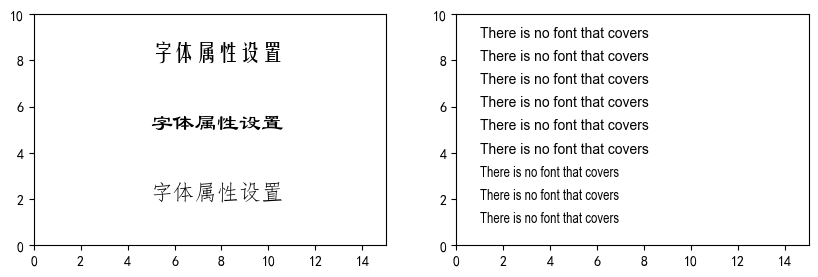

In [68]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建示例数据


plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.xlim(0, 15)  # 设置坐标单位，更好的设置坐标
plt.ylim(0, 10)  # 设置坐标单位

fontdict = {
    'family': 'FangSong',      # 字体族
    'size': 16,             # 字号
    'weight': 'bold',       # 字重
    'style': 'italic'       # 字体样式
}
plt.text(5, 2, "字体属性设置", fontdict=fontdict)

fontdict["family"]="LiSu"
plt.text(5, 5, "字体属性设置", fontdict=fontdict)

fontdict["family"]="FZYaoTi"
plt.text(5, 8, "字体属性设置", fontdict=fontdict)

# ----------------------------
plt.subplot(122)
plt.xlim(0, 15)  # 设置坐标单位，更好的设置坐标
plt.ylim(0, 10)  # 设置坐标单位
stretchs = [
    'ultra-condensed', 
    'extra-condensed', 
    'condensed', 
    'semi-condensed', 
    'normal', 
    'semi-expanded', 
    'expanded', 
    'extra-expanded', 
    'ultra-expanded']
for i, stretch in  enumerate(stretchs):
    plt.text(1, 1+i, "There is no font that covers", stretch=stretch, fontfamily="Arial")

plt.show()

- 代码说明：
    - `plt.text(1, 1+i, "There is no font that covers", stretch=stretch, fontfamily="Arial")`我们混合使用了font前缀(fontfamily)与直接(stretch)使用属性的方式。
    - stretch字体属性，与variant一样，需要字库支持才行。所以我们选择了Arial字体演示。这种属性对汉字来讲目前支持的意义不大。

- 其他来自Text对象的属性，我们不在后面的Text对象介绍的时候，在详细说明，下面使用例子来说体验下：

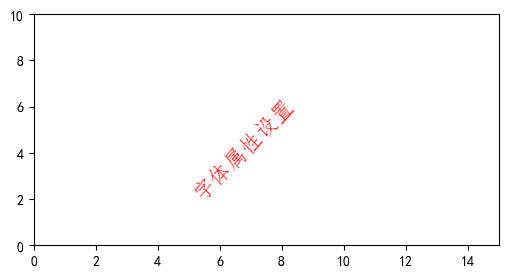

In [78]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建示例数据


plt.figure(figsize=(6, 3))
plt.xlim(0, 15)  # 设置坐标单位，更好的设置坐标
plt.ylim(0, 10)  # 设置坐标单位

fontdict = {
    'family': ['FangSong',"SimHei"],      # 字体族
    'size': 16,             # 字号
    'weight': 'bold',       # 字重
    'style': 'italic'       # 字体样式
}
plt.text(5, 2, "字体属性设置", fontdict=fontdict, color="red", rotation=45)

plt.show()

- 代码说明：
    - color设置文本颜色，而不是字体颜色（字体是没有颜色的，至少字库中没有）
    - rotation设置文本绘制的旋转角度。
    - 字体属性可以使用列表设置多个值。

#### figtext函数

- figtext的使用完全一样，只是使用的坐标系不一样。figtext是在Figure的画布上绘制。

- 我们直接列出函数原型，其他不再赘述。

```python
matplotlib.pyplot.figtext(
    x, y, 
    s, 
    fontdict=None, 
    **kwargs)
```

- x,y的坐标指定在`[0,1]`之间，不过坐标系可以使用Text的transform属性重新设置。下面我们仅仅用一个例子说明。
    - transform对text函数也一样可以改变坐标系。但是Axes改变坐标系有很多方法，transform只是其中一种。

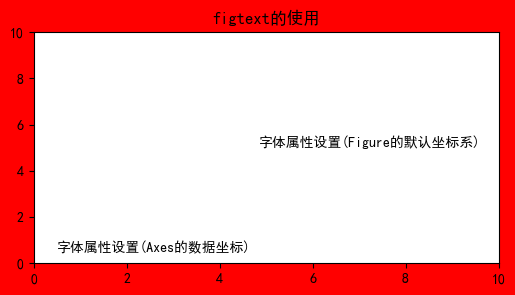

In [102]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建Figure
plt.figure(figsize=(6, 3), facecolor="red")
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.figtext(0.5, 0.5, "字体属性设置(Figure的默认坐标系)")  # 不能使用0-1之外的坐标点（当然可以使用，但是画布就很大了）
plt.figtext(0.5, 0.5, "字体属性设置(Axes的数据坐标)", transform=plt.gca().transData)

plt.title("figtext的使用")  # 因为没有Axes，所以不显示，我们使用这个语句，默认生成一个Axes对象，默认Axes坐标系从Figure继承
plt.show()


- 代码说明：
    - 我们可以通过transform参数（来自Text对象的属性），指定figtext使用的坐标系，而坐标系也确定了我们使用坐标(x，y)的单位。在代码的例子中，同样是(0.5, 0.5)在不同的坐标系下面，其位置明显不一样。
    - plt.gca().transData坐标系使用了Axes对象中的数据坐标系（数据坐标系是使用xlim与ylim数据建立的坐标系）
        - 比如`plt.xlim(0, 10)`与`plt.ylim(0, 10)`,就意味着我们的坐标参照单位是:x轴在0-10之间，y轴在0-10之间。
        - 可以调整xlim与ylim的值来体验这种坐标系的作用。
    - 关于变换，我们会单独使用主题说明，掌握好matplotlib中的Transform可以更精确的确定绘制内容的位置。

### (2) 注释标注-annotate函数

- annotate()函数是负责在Axes中添加注释（文本和箭头）绘制，annotate与text的区别就是annotate在文本说明与数据点之间使用箭头说明注释关系。

- annotate函数的原型定义与参数说明：

```python
matplotlib.pyplot.annotate(
    text,  # 注释（我们有的时候也称标注）的文本内容，类型是字符串str。
    xy,    # 需要注释的坐标点。参数类型与格式(float, float)
    xytext=None,  # 注释的文本内容绘制的位置坐标。参数类型与格式(float, float)，默认值就是使用xy的值。
    xycoords='data',  # 设置xy参数采用的坐标系（就是我们上面transform参数指定的作用一样），参数类型是str,或者(str,str),Artist对象，Transform对象，可调用对象。默认值是"data"（根据上面的例子代码，应该猜出来是Axes.transData坐标系）
    textcoords=None,  # xytext使用的坐标系，默认是xycoords的值。
    arrowprops=None,  # 设置箭头的属性，来自FancyArrowPatch对象的属性，默认是None，表示不会绘制箭头。
    annotation_clip=None, # 设置是否裁剪超出Axes区域的注释内容。参数是bool类型，True表示裁剪，False表示绘制。默认值None，表示当注释内容超出坐标系，且坐标系是data类型的时候才裁剪。
    **kwargs  # 来自Text对象的属性，用来设置注释的文本的修饰属性。
)
```

函数的返回值：Annotation对象。

- xycoords与textcoords参数的坐标系说明：
    - 参数是str：指定坐标系类型，能支持的坐标系类型下面表格中会列出。
    - 参数是(str, str)：指定x，y使用不同的坐标系（混合坐标系）。
    - 参数是Artist对象：指定坐标系使用Artist对象的Bbox数据。
    - 参数Transform对象：使用Transform对象把xy转换为输出坐标（屏幕坐标）。
    - 参数是可调用对象或者函数：函数原型必须满足下面两种定义：
        - `def transform(renderer) -> Bbox`：与Artist中Bbox属性一样。
        - `def transform(renderer) -> Transform`：与Transform对象
            - renderer是绘制器（是RendererBase对象），包含物理坐标系。

- 尽管上面看起来有点复杂，大部分的时候，我们使用默认的'data'就非常方便了。也可以使用Figure那个`[0,1]`标准坐标系。下面我们列出xycoords与textcoords使用str可以支持的坐标系。

- xycoords为str的时候支持的坐标系：
    - `'figure points'`:原点在Figure左下角，距离度量单位是磅(Points)
    - `'figure pixels'`:原点在Figure左下角，距离度量单位是像素(Pixel)
    - `'figure fraction'`:原点在Figure左下角，距离度量单位是比例(Fraction)，比如在x轴0.3的位置（30%的位置），Figure的默认坐标系，等于把x轴长度看成1的度量方式。
    - `'subfigure points'`:原点在SubFigure左下角，距离度量单位是磅(Points)
    - `'subfigure pixels'`:原点在SubFigure左下角，距离度量单位是像素(Pixel)
    - `'subfigure fraction'`:原点在SubFigure左下角，，距离度量单位是比例(Fraction)
    - `'axes points'`:原点在Axes左下角，，距离度量单位是比例(Fraction)
    - `'axes pixels'`:原点在Axes左下角，距离度量单位是像素(Pixel)
    - `'axes fraction'`:原点在Axes左下角，，距离度量单位是比例(Fraction)
    - `'data'`: 使用标注对象的坐标系。这个坐标系由xlim与ylim属性设置。这是是默认值。
    - `'polar'`:使用极坐标系。

- 注意我们在上面使用了figure与subfigure两个名词：
    - 对于父Figure来说，figure与subfigure都是一样的，因为编码清晰，可以在sunfigure的场景下使用sunfigure。
    - 换句话说subfigure其实也是figure，只是嵌套而已。下面是一个图示(怎么嵌套figure我们在后面有专门的主题介绍)：

>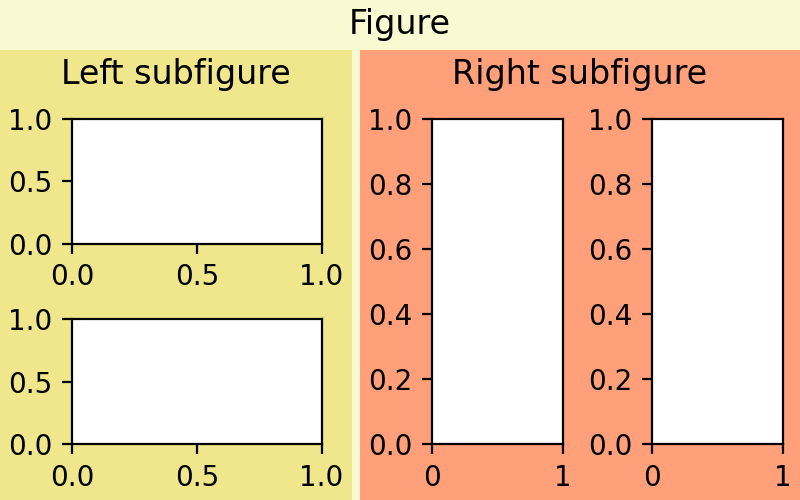

- textcoords参数能使用的坐标系，一般不使用绝对坐标系(也可以使用上面的坐标系)，而使用相对坐标系会更加方便：
    - `'offset points'`:到xy坐标的偏离坐标系，单位是points。
    - `'offset pixels'`:到xy坐标的偏离坐标系，单位是pixels。
    - `'offset fontsize'`:到xy坐标的偏离坐标系，单位是字体大小（注意：在这里比例fraction没有意义了）。

- arrowprops参数说明：
    - 该参数设置后，不为None值，才会绘制箭头。该参数类型是字典，用来设置箭头的属性。绘制的箭头是FancyArrowPatch对象，箭头分两种
        - 简单箭头：字典中没有arrowstyle字段的就是简单箭头
        - 花式箭头：字典中设置arrowstyle字段的就是花式箭头。

- 简单箭头可以设置的字典字段：
    - width：箭头线的宽度，单位是Points。
    - headwidth：箭头的宽度，单位是Points。
    - headlength：箭头的长度，单位是Points。
    - shrink：控制箭头两端与连接点（xy与xytext）之间的收缩比例（是箭头总长比例）。
        - 就是箭头不是从xy开始，也不是直接在xytext结束，而是保留一点距离，这个距离由shrink按照总长百分比设置。
    - 其他FancyArrowPatch对象的属性

- 花式箭头可以设置的属性
    - arrowstyle：箭头样式
    - connectionstyle：箭头连接线样式
    - relpos：箭头开始的位置（采用的是绘制文本的坐标系），原点在(0, 0), 坐标框右上角坐标是(1, 1)
    - patchA：箭头开始链接的图形A（Patch对象）
    - patchB：箭头尾巴链接的图形B（Patch对象）
    - shrinkA：箭头开始离图形A的距离（单位Points）
    - shrinkB：箭头尾巴离图形B的距离（单位Points）
    - mutation_scale：arrowstyle属性被放大缩小参数，默认值是1.
    - mutation_aspect：控制箭头头部尺寸相对于箭头线宽的比例关系，特别是在非均匀缩放的情况下。参数类型是float
    - 其他FancyArrowPatch对象的属性

- 箭头样式arrowstyle的值：
    - 下面我们使用代码来说明这些值。

In [124]:
from matplotlib.patches import ArrowStyle
import inspect

styles = ArrowStyle.get_styles()
for stylename, stylecls in styles.items():
    # print(stylename, ":", inspect.signature(stylecls))
    print(stylename, ":", stylecls)

- : <class 'matplotlib.patches.ArrowStyle.Curve'>
<- : <class 'matplotlib.patches.ArrowStyle.CurveA'>
-> : <class 'matplotlib.patches.ArrowStyle.CurveB'>
<-> : <class 'matplotlib.patches.ArrowStyle.CurveAB'>
<|- : <class 'matplotlib.patches.ArrowStyle.CurveFilledA'>
-|> : <class 'matplotlib.patches.ArrowStyle.CurveFilledB'>
<|-|> : <class 'matplotlib.patches.ArrowStyle.CurveFilledAB'>
]- : <class 'matplotlib.patches.ArrowStyle.BracketA'>
-[ : <class 'matplotlib.patches.ArrowStyle.BracketB'>
]-[ : <class 'matplotlib.patches.ArrowStyle.BracketAB'>
|-| : <class 'matplotlib.patches.ArrowStyle.BarAB'>
]-> : <class 'matplotlib.patches.ArrowStyle.BracketCurve'>
<-[ : <class 'matplotlib.patches.ArrowStyle.CurveBracket'>
simple : <class 'matplotlib.patches.ArrowStyle.Simple'>
fancy : <class 'matplotlib.patches.ArrowStyle.Fancy'>
wedge : <class 'matplotlib.patches.ArrowStyle.Wedge'>


- 代码说明：
    - 我们使用了python中的inspect模块，inspect模块获取活动对象信息的强大工具，主要功能有：
        - 类型检查：检查对象类型、可调用性等
        - 源码获取：获取源代码、文档字符串
        - 类与函数分析：检查参数、继承关系、方法等
        - 调用栈分析：获取当前调用栈、帧信息
        - **实时对象检查**：检查运行时的对象状态（上面代码`inspect.signature(stylecls)`就是用来获取类别的构造器原型定义，同时可以获取绝大部分参数与默认值）。
    - 请把注释的代码回复运行，体验输出的数据信息。

- text，xy，xytext，arrowprops参数的使用例子：

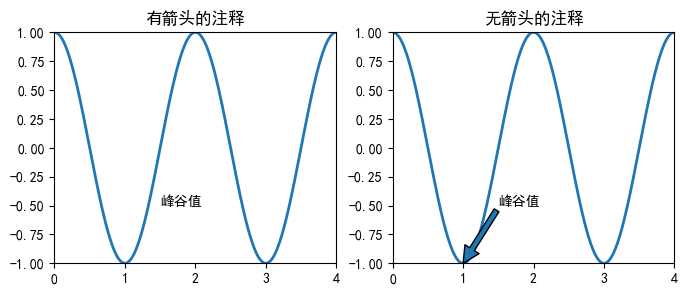

In [112]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 数据
x = np.arange(0, 4.0, 0.01)
y = np.cos(np.pi * x)

# 创建Figure
plt.figure(figsize=(8, 3))

# 没有箭头的注释
plt.subplot(121)
plt.xlim(0, 4)
plt.ylim(-1, 1)

plt.plot(x, y, linewidth=2)
# 在峰谷进行注释
plt.annotate('峰谷值', xy=(1, -1), xytext=(1.5, -0.5),)
plt.title("有箭头的注释") 

# 有箭头的注释
plt.subplot(122)
plt.xlim(0, 4)
plt.ylim(-1, 1)
plt.plot(x, y, linewidth=2)
# 在峰谷进行注释
plt.annotate('峰谷值', xy=(1, -1), xytext=(1.5, -0.5), arrowprops=dict())
plt.title("无箭头的注释")

plt.show()


- 代码说明：
    - `arrowprops=dict()`参数没有设置任何字段，但是arrowprops不为None，所以绘制箭头，所有箭头采用默认属性。

- 简单样式的使用例子
    - 通过对比来说明每个箭头样式值的使用。

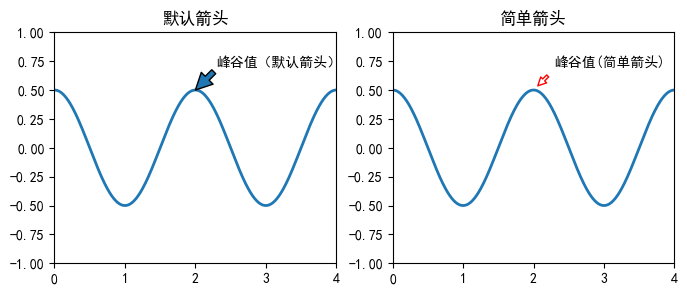

In [21]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 数据
x = np.arange(0, 4.0, 0.01)
y = np.cos(np.pi * x) * 0.5

# 创建Figure
plt.figure(figsize=(8, 3))

# 没有箭头的注释
plt.subplot(121)
plt.xlim(0, 4)
plt.ylim(-1, 1)

plt.plot(x, y, linewidth=2)
# 在峰谷进行注释
plt.annotate('峰谷值（默认箭头）',  xy=(2, 0.5), xytext=(2.3, 0.7),  arrowprops=dict())
plt.title("默认箭头") 

# 有箭头的注释
plt.subplot(122)
plt.xlim(0, 4)
plt.ylim(-1, 1)
plt.plot(x, y, linewidth=2)
# 在峰谷进行注释
arrowprops={}
arrowprops["width"] = 2
arrowprops["headwidth"] = 6
arrowprops["headlength"] = 6
arrowprops["shrink"] = 0.2
arrowprops["color"] = "red"   # 来自FancyArrowPatch对象的属性（仅用2个作为例子）
arrowprops["fill"] = False

plt.annotate('峰谷值(简单箭头)', xy=(2, 0.5), xytext=(2.3, 0.7), arrowprops=arrowprops)
plt.title("简单箭头")

plt.show()


- 代码说明：
    - 从代码运行结果，我们可以体验箭头的参数含义:
        - width是箭头线的宽度
        - headwidth与headlength可以控制箭头大小。
        - shrink是箭头端点到xy与xytext两个点的间隔距离，使用的是xy到xytext之间距离的比例。
        - 在FancyArrowPatch对象中常用的属性，基本上就是线条样式，颜色，填充图案等属性。

- 花式样式的使用例子：可视化输出箭头样式信息
    - 我们把上面的箭头样式信息使用文本(text)与注释(annotate)可视化输出

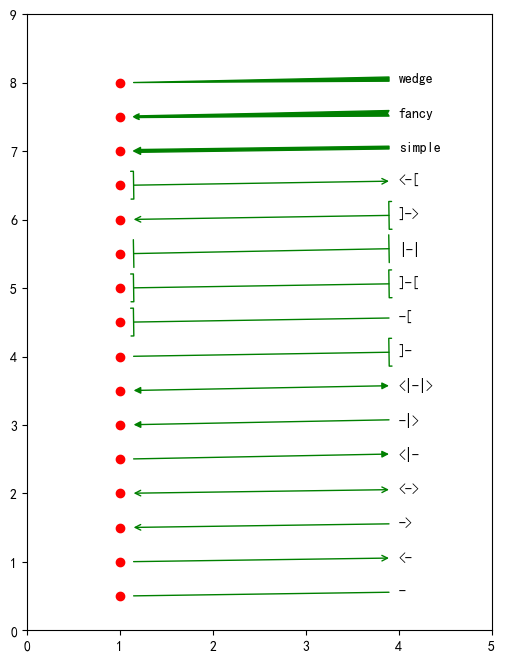

In [147]:
from matplotlib.patches import ArrowStyle
import inspect

# arrowstyle的信息获取
styles = ArrowStyle.get_styles()

plt.figure(figsize=(6, 8))
plt.xlim(0, 5)
plt.ylim(0, 9)
for i, (stylename, stylecls) in enumerate(styles.items()):
    xy_x = 1
    xytext_x = 4
    y = 0.5 + i * 0.5
    [p] = plt.plot(xy_x, y, marker="o", color="red")
    arrowprops=dict()
    arrowprops["arrowstyle"] = stylename
    arrowprops["color"] = "green"
    arrowprops["shrinkA"] = 5
    arrowprops["shrinkB"] = 5
    arrowprops["patchB"] = p
    plt.annotate(stylename, xy=(xy_x, y), xytext=(xytext_x, y), arrowprops=arrowprops)
plt.show()


- 代码说明
    - arrowstyle的取值就是图表中右边显示的字符串。
    - shrinkA，shrinkB控制箭头与xy，xytext的间距。
    - patchA，patchB可以设置箭头两端的图形。

- 花式箭头的connectionstyle属性应用例子：
    - connectionstyle属性可以设置箭头的连接线的样式，值的类型可以是str、ConnectionStyle对象、None。
        - None表示是默认值：'arc3'
        - str使用字符串表示连接线样式(这种表达方式是matplotlib中很多，比如linestyle也使用这种方式)：
            - 'arc3'：使用例子'arc3,rad=0.2'
                - 支持参数(含默认值)：rad=0.0
            - 'angle3'：使用例子'angle3, angleA=30, angleB=60'
                - 支持参数(含默认值)：angleA=90, angleB=0
            - 'angle'：使用例子'angle, angleA=30, angleA=45, angleB=180, rad=0.5'
                - 支持参数(含默认值)：angleA=90, angleB=0, rad=0.0
            - 'arc'：使用例子'arc, angleA=30, angleB=45, armA=15, armB=30, rad=0.3'
                - 支持参数(含默认值)：angleA=0, angleB=0, armA=15, armB=30, rad=0.0
            - 'bar'：使用例子'bar, armA=15.0, armB=30.0, fraction=0.3, angle=45'
                - 支持参数(含默认值)：armA=0.0, armB=0.0, fraction=0.3, angle=None
        - 直接使用ConnectionStyle对象。

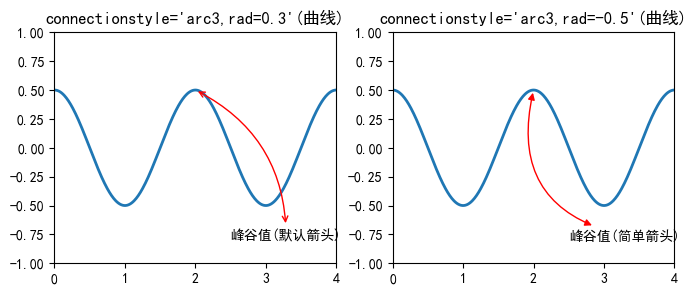

In [98]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 数据
x = np.arange(0, 4.0, 0.01)
y = np.cos(np.pi * x) * 0.5

# 创建Figure
plt.figure(figsize=(8, 3))

# 没有箭头的注释
plt.subplot(121)
plt.xlim(0, 4)
plt.ylim(-1, 1)
plt.plot(x, y, linewidth=2)
arrowprops={}
arrowprops["arrowstyle"] = "<->"
arrowprops["connectionstyle"] = "arc3,rad=0.3"
arrowprops["color"] = "red"
plt.annotate('峰谷值(默认箭头)', xy=(2, 0.5), xytext=(2.5, -0.8), arrowprops=arrowprops)
plt.title("connectionstyle='arc3,rad=0.3'(曲线)") 

# 有箭头的注释
plt.subplot(122)
plt.xlim(0, 4)
plt.ylim(-1, 1)
plt.plot(x, y, linewidth=2)
# 在峰谷进行注释
arrowprops={}
arrowprops={}
arrowprops["arrowstyle"] = "<|-|>"
arrowprops["connectionstyle"] = "arc3,rad=-0.5"
arrowprops["color"] = "red"
plt.annotate('峰谷值(简单箭头)', xy=(2, 0.5), xytext=(2.5, -0.8), arrowprops=arrowprops)
plt.title("connectionstyle='arc3,rad=-0.5'(曲线)")

plt.show()


- 代码说明：
    - `arc3`:是二次Bézier(贝塞尔)**曲线**，创建曲线时，中间控制点C1位于距离起点C0和终点C2相同的距离处，C1到连接C0-C2直线的垂直距离是rad乘以C0-C2距离。rad就是`arc3`的唯一参数。
    - rad使用正负，可以控制曲线的弧度方向。如果rad是0，则是直线（意味C1在C0-C2的连接线上）。
    - rad的绝对值大小，决定连接线的弧度大小。rad越大，C1越原理C0-C2连线，连接曲线弧度越大。
    - arc3对应的对象是：`class Arc3(rad=0.0)`

- arc连接线的使用例子
    - arc对应的对象是：`class Arc(angleA=0, angleB=0, armA=None, armB=None, rad=0.0)`。
    - arc是两段连续的Bézier**路径**。这样就容易理解上面的参数含义。
    - 角度：0°表示向右，90°表示向上，180°表示向左，270°表示向下

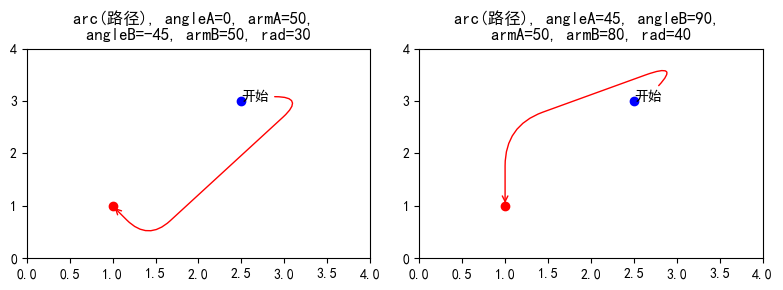

In [99]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 数据
xy = (1, 1)
xytext = (2.5, 3)

# 创建Figure
plt.figure(figsize=(8, 3))

# 没有箭头的注释
plt.subplot(121)
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.plot(xy[0], xy[1], "o", color="red")   # 结束点
plt.plot(xytext[0], xytext[1], "o", color="blue")  # 开始点
arrowprops={}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "arc, angleA=0, armA=50, angleB=-45, armB=50, rad=30"
arrowprops["color"] = "red"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)
plt.title("arc(路径), angleA=0, armA=50, \nangleB=-45, armB=50, rad=30") 

# 有箭头的注释
plt.subplot(122)
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.plot(xy[0], xy[1], "o", color="red")   # 结束点
plt.plot(xytext[0], xytext[1], "o", color="blue")  # 开始点
# 在峰谷进行注释
arrowprops={}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "arc, angleA=45, angleB=90, armA=50, armB=80, rad=40"
arrowprops["color"] = "red"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)
plt.title("arc(路径), angleA=45, angleB=90, \narmA=50, armB=80, rad=40")

plt.tight_layout()
plt.show()


- 代码说明：
    - `arrowprops["connectionstyle"] = "arc, angleA=45, angleB=90, armA=50, armB=80, rad=40"`代码中参数对连接线的影响：
        - 从xy开始，沿angleA=45°方向，绘制armA=90长的线段L1，终点D1。
        - 从xytext开始，沿angleB=90°方向，绘制armB=80长的线段L2，终点D2。
        - 链接L1与L2的终点端点D1与D2。
        - 连接点的采用圆角，圆角的半径是40。

- angle连接线的使用例子
    - angle线由`class Angle(angleA=90, angleB=0, rad=0.0)`对象负责。
        - 在两点之间创建一条简单的二次贝塞尔**路径**。中间控制点位于两条线的交点处，这两条线分别与起点和终点相交。
        - 从起点开始的直线角度是angleA，从终点开始的直线角度是angleB。
        - 交点处使用rad控制圆角的弧度。
    - angle3线由`class Angle3(angleA=90, angleB=0)`对象负责。
        - 在两点之间创建一条简单的二次贝塞尔**曲线**。中间控制点位于两条线的交点处，这两条线分别与起点和终点相交。
        - 从起点开始的直线角度是angleA，从终点开始的直线角度是angleB。

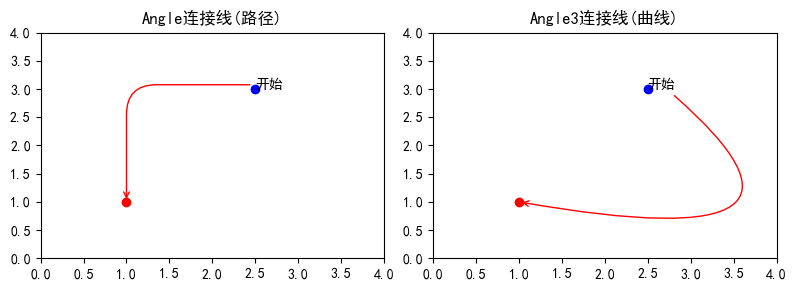

In [100]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 数据
xy = (1, 1)
xytext = (2.5, 3)

# 创建Figure
plt.figure(figsize=(8, 3))

# 没有箭头的注释
plt.subplot(121)
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.plot(xy[0], xy[1], "o", color="red")   # 结束点
plt.plot(xytext[0], xytext[1], "o", color="blue")  # 开始点
arrowprops={}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "angle, angleA=180, angleB=90, rad=30.0"
arrowprops["color"] = "red"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)
plt.title("Angle连接线(路径)") 

# 有箭头的注释
plt.subplot(122)
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.plot(xy[0], xy[1], "o", color="red")   # 结束点
plt.plot(xytext[0], xytext[1], "o", color="blue")  # 开始点
# 在峰谷进行注释
arrowprops={}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "angle3, angleA=-40, angleB=-10"
arrowprops["color"] = "red"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)
plt.title("Angle3连接线(曲线)")

plt.tight_layout()
plt.show()


- 代码说明：
    - `arrowprops["connectionstyle"] = "angle, angleA=180, angleB=90, rad=30.0"`控制连接线的说明：
        - 从开始点A，沿180度方向的直线。
        - 从结束点B，沿90度方向的直线。
        - 在两条线相交点C，分别绘制交点C到A、B的两个线段，线段在交点的折角，采用圆角，圆角的半径是rad=30.
    - `arrowprops["connectionstyle"] = "angle3, angleA=-40, angleB=-10"`控制连接线说明：
        - 从开始点A，沿-40度方向的直线。
        - 从结束点B，沿-10度方向的直线。
        - 两条直线相较于C处，由ABC三个点控制绘制贝塞尔曲线。

- 我们从上面的绘制中故意区分了**路径**与**曲线**
    - 贝塞尔曲线的次数是由控制点决定的。2个控制点是1次贝塞尔曲线，3个点是2次贝塞尔曲线。我们这里的控制点都是3个。官方文档使用`path`与`curve`来区分绘制的具体算法。(这里不解释贝塞尔曲线的具体绘制算法)
        - 3结尾的都是使用`curve`（曲线）描述，没有3结尾的使用的是`path`（直线）
        - 在文档中都贝塞尔曲线使用的是`quadratic Bézier`(2次贝塞尔曲线)是因为控制点都是三个。

- bar连接线的使用例子
    - Bar类的参数：`class Bar(armA=0.0, armB=0.0, fraction=0.3, angle=None)`
        - 尽管通过前面的使用，对这几个参数具有字面意义上的理解。我们使用例子来充分理解四个参数的具体意义。

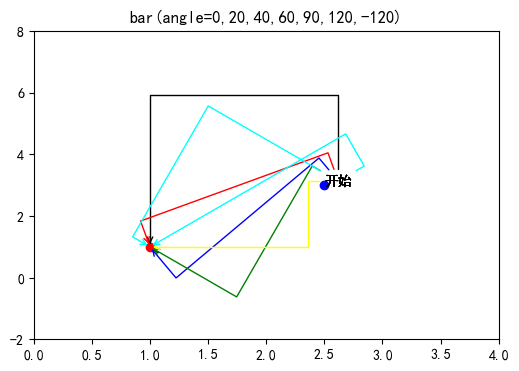

In [172]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 数据
xy = (1, 1)
xytext = (2.5, 3)

# 创建Figure
plt.figure(figsize=(6, 4))
plt.xlim(0, 4)
plt.ylim(-2, 8)
plt.plot(xy[0], xy[1], "o", color="red")   # 结束点
plt.plot(xytext[0], xytext[1], "o", color="blue")  # 开始点
arrowprops={}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=30.0, armB=20.0, fraction=0.0, angle=0"
arrowprops["color"] = "black"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=30.0, armB=20.0, fraction=0.0, angle=20"
arrowprops["color"] = "red"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=30.0, armB=20.0, fraction=0.0, angle=40"
arrowprops["color"] = "blue"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=30.0, armB=20.0, fraction=0.0, angle=60"
arrowprops["color"] = "green"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=30.0, armB=20.0, fraction=0.0, angle=90"
arrowprops["color"] = "yellow"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=30.0, armB=20.0, fraction=0.0, angle=120"
arrowprops["color"] = "cyan"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=30.0, armB=20.0, fraction=0.0, angle=-120"
arrowprops["color"] = "cyan"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

plt.title("bar(angle=0,20,40,60,90,120,-120)") 
plt.show()


- 代码说明；
    - angle控制连线与x轴的角度。
        - 连线到开始点A的线为armA线段。
        - 连线到结束点B的线为armB线段。
        - arm线一定垂直于连线。
    - 在代码的最后，我们使用了-120°，与120°都是使用的翠色(cyan)。注意角度从x轴开始，按照逆时针为正，顺时针为负。
    - 如果不设置angle，则连线平行于AB线段。

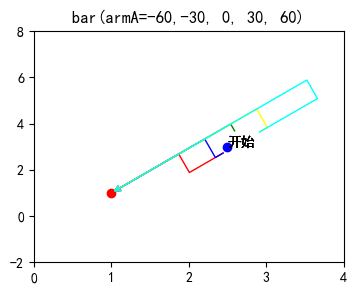

In [175]:
# %matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 数据
xy = (1, 1)
xytext = (2.5, 3)

# 创建Figure
plt.figure(figsize=(4, 3))

plt.xlim(0, 4)
plt.ylim(-2, 8)
plt.plot(xy[0], xy[1], "o", color="red")   # 结束点
plt.plot(xytext[0], xytext[1], "o", color="blue")  # 开始点
arrowprops={}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=-60.0, armB=20.0, fraction=0.0, angle=120"
arrowprops["color"] = "red"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=-30.0, armB=40.0, fraction=0.0, angle=120"
arrowprops["color"] = "blue"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=0.0, armB=40.0, fraction=0.0, angle=120"
arrowprops["color"] = "green"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=30.0, armB=40.0, fraction=0.0, angle=120"
arrowprops["color"] = "yellow"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

arrowprops["connectionstyle"] = "bar, armA=60.0, armB=40.0, fraction=0.2, angle=120"
arrowprops["color"] = "cyan"
plt.annotate('开始', xy=xy, xytext=xytext, arrowprops=arrowprops)

plt.title("bar(armA=-60,-30, 0, 30, 60)") 

plt.show()


- 代码说明：
    - 一定区分清楚连线，armA，armB三个线段。在上面5条连线都是一样长，但是armA与armB是不一样的。
    - 我们看得出armA，armB只指的不是固定长度值，而是确保两个arm的最小值。
        - 在代码中armB因为取值较小，实际长度已经大于armB的长度，所以armB在实际长度内调整，都不会影响连线的绘制。
    -  我们在最后一个注释中，调整了`fraction=0.2`，导致armA的长度变长，armB也因此变长，实际armA，armB，fraction三者的关系是：
        - armA与armB的绘制长度，先按照如下公式计算：
            - 计算armA绘制长度l= armA + fraction * AB的距离，确定连线的位置
            - 再计算B到连线的距离，如果距离大于等于armB + fraction * AB的距离，则就按照计算的连线位置绘制，反之，则以armB + fraction * AB的距离确定连线的位置。
        - armA保证实际绘制的armA的最小值。
        - armB保证实际绘制的armB的最小值。
        - 在保证armA与armB最小的条件下，优先保证开始点与结束点在连线的一侧。可以使用正负armA与armB来控制连线与AB点的位置关系。

- patchA, patchB参数的使用例子
    - 使用patchA, patchB两个参数设置箭头的两端样式为图形样式（就是Patch图形对象）。
        - Patch对象是一个具有填充颜色(color)与边界颜色edgecolor的图形。
    - Patch我们在前面简单介绍过，后面会有专门注意介绍。比如：Circle，Polygon，Rectangle等。

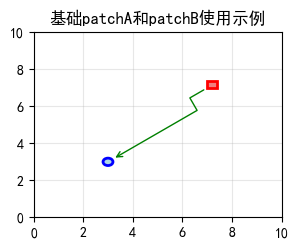

In [252]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

xy=(3, 3)
xytext = (7, 7)
# 创建基础图形
plt.figure(figsize=(3.2, 2.4))
plt.xlim(0, 10)
plt.ylim(0, 10)


# 创建两个圆形patch
circle1 = patches.Circle(xy, radius=0.2, facecolor='lightblue', edgecolor='blue', linewidth=2)
circle2 = patches.Rectangle(xytext, width=0.4, height=0.4, facecolor='lightcoral', edgecolor='red', linewidth=2)

# 将patch添加到图形中
plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)

arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=20.0, armB=10.0, fraction=0.0, angle=120"
arrowprops["color"] = "green"
arrowprops["patchA"] = circle2
arrowprops["patchB"] = circle1
# 使用patchA和patchB连接两个圆形
plt.annotate('', xy=xy,  xytext=xytext, arrowprops=arrowprops)

plt.title('基础patchA和patchB使用示例')
plt.grid(True, alpha=0.3)
plt.show()

- 代码说明：
    - 当添加patchA与patchB的时候，需要注意开始点与结束点不要搞混淆。需要开始位置对应开始位置，结束位置对应结束位置。
        - xy是注释的目标位置，使用B表示
        - xytext是注释的开始位置（就是注释文本内容的位置），使用A表示。

- 花式样式中mutation_scale与mutation_aspect属性的使用例子
    - mutation_scale和mutation_aspect是控制箭头头部样式和尺寸的重要参数，特别在使用花式箭头(arrowstyle)时非常有用。
    - mutation_scale: 控制箭头整体的缩放比例，默认值1。
    - mutation_aspect: 控制箭头宽度和高度的比例（宽高比），默认值None。
    - 我们顺便演示了shrinkA，shrinkB的使用，这两个参数的默认值是2。

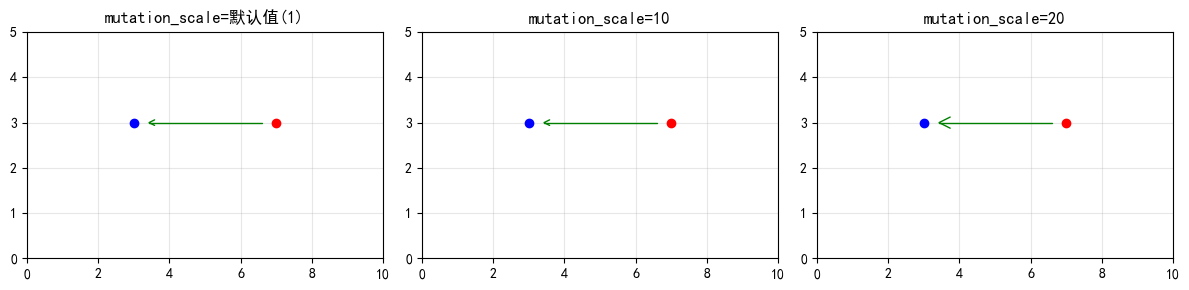

In [280]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

xy=(3, 3)
xytext = (7, 3)
# 创建基础图形
plt.figure(figsize=(12, 3))

plt.subplot(131)
plt.xlim(0, 10)
plt.ylim(0, 5)
plt.plot(xy[0], xy[1], "bo")
plt.plot(xytext[0], xytext[1], "ro")  # 开始点A
arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=0.0, armB=0.0, fraction=0.0, angle=0"
arrowprops["color"] = "green"
arrowprops["shrinkA"] = 10
arrowprops["shrinkB"] = 10
# arrowprops["mutation_scale"] = 1
# 使用patchA和patchB连接两个圆形
plt.annotate('', xy=xy,  xytext=xytext, arrowprops=arrowprops)
plt.title('mutation_scale=默认值(1)')   # 从效果看，默认值应该是10。
plt.grid(True, alpha=0.3)
#######################################
plt.subplot(132)
plt.xlim(0, 10)
plt.ylim(0, 5)
plt.plot(xy[0], xy[1], "bo")
plt.plot(xytext[0], xytext[1], "ro")  # 开始点A
arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=0.0, armB=0.0, fraction=0.0, angle=0"
arrowprops["color"] = "green"
arrowprops["shrinkA"] = 10
arrowprops["shrinkB"] = 10
arrowprops["mutation_scale"] = 10
# 使用patchA和patchB连接两个圆形
plt.annotate('', xy=xy,  xytext=xytext, arrowprops=arrowprops)
plt.title('mutation_scale=10')
plt.grid(True, alpha=0.3)
#######################################
plt.subplot(133)
plt.xlim(0, 10)
plt.ylim(0, 5)
plt.plot(xy[0], xy[1], "bo")
plt.plot(xytext[0], xytext[1], "ro")  # 开始点A
arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=0.0, armB=0.0, fraction=0.0, angle=0"
arrowprops["color"] = "green"
arrowprops["shrinkA"] = 10
arrowprops["shrinkB"] = 10
arrowprops["mutation_scale"] = 20
# 使用patchA和patchB连接两个圆形
plt.annotate('', xy=xy,  xytext=xytext, arrowprops=arrowprops)
plt.title('mutation_scale=20')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- 代码说明：
    - 官方文档提供的是：mutation_scale默认值是1，但实际效果应该是10.
    - mutation_scale是箭头按照比例缩放。

- 参数mutation_aspect使用例子：
    - 控制箭头的高宽度比。

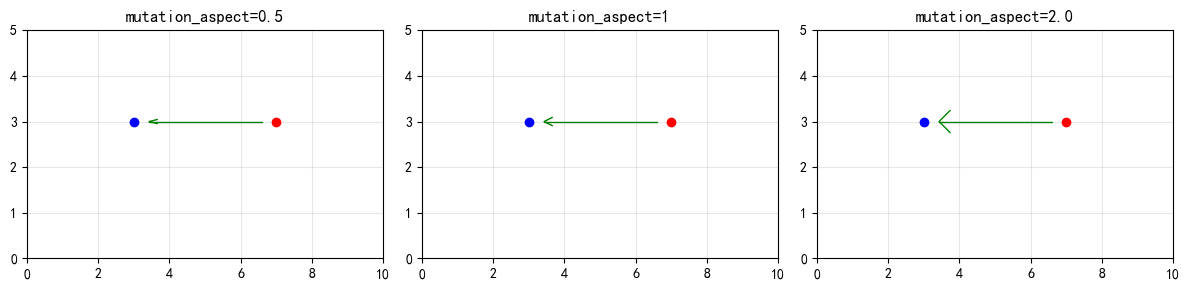

In [282]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

xy=(3, 3)
xytext = (7, 3)
# 创建基础图形
plt.figure(figsize=(12, 3))

plt.subplot(131)
plt.xlim(0, 10)
plt.ylim(0, 5)
plt.plot(xy[0], xy[1], "bo")
plt.plot(xytext[0], xytext[1], "ro")  # 开始点A
arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=0.0, armB=0.0, fraction=0.0, angle=0"
arrowprops["color"] = "green"
arrowprops["shrinkA"] = 10
arrowprops["shrinkB"] = 10
arrowprops["mutation_scale"] = 15
arrowprops["mutation_aspect"] = 0.5
# arrowprops["mutation_scale"] = 1
# 使用patchA和patchB连接两个圆形
plt.annotate('', xy=xy,  xytext=xytext, arrowprops=arrowprops)
plt.title('mutation_aspect=0.5')   # 从效果看，默认值应该是10。
plt.grid(True, alpha=0.3)
#######################################
plt.subplot(132)
plt.xlim(0, 10)
plt.ylim(0, 5)
plt.plot(xy[0], xy[1], "bo")
plt.plot(xytext[0], xytext[1], "ro")  # 开始点A
arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=0.0, armB=0.0, fraction=0.0, angle=0"
arrowprops["color"] = "green"
arrowprops["shrinkA"] = 10
arrowprops["shrinkB"] = 10
arrowprops["mutation_scale"] = 15
arrowprops["mutation_aspect"] = 1.0
# 使用patchA和patchB连接两个圆形
plt.annotate('', xy=xy,  xytext=xytext, arrowprops=arrowprops)
plt.title('mutation_aspect=1')
plt.grid(True, alpha=0.3)
#######################################
plt.subplot(133)
plt.xlim(0, 10)
plt.ylim(0, 5)
plt.plot(xy[0], xy[1], "bo")
plt.plot(xytext[0], xytext[1], "ro")  # 开始点A
arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=0.0, armB=0.0, fraction=0.0, angle=0"
arrowprops["color"] = "green"
arrowprops["shrinkA"] = 10
arrowprops["shrinkB"] = 10
arrowprops["mutation_scale"] = 20
arrowprops["mutation_aspect"] = 2.0
# 使用patchA和patchB连接两个圆形
plt.annotate('', xy=xy,  xytext=xytext, arrowprops=arrowprops)
plt.title('mutation_aspect=2.0')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- annotate函数中来自Text对象的有用属性：
    - 文本注释的边框bbox。
    - 文本注释的颜色color。
    - 文本注释的字体fontproperties。
- color与fontproperties参数不做详细介绍，直接使用代码说明。

- bbox属性说明：
    - bbox类型是dict类型，字典字段来自patches.FancyBboxPatch对象，重点是boxstyle（对应matplotlib.patches.BoxStyle）。
        - square，pad=0.3
        - circle：pad=0.3
        - ellipse：pad=0.3
        - larrow：pad=0.3
        - rarrow：pad=0.3
        - darrow：pad=0.3
        - round：pad=0.3, rounding_size=None
        - round4：pad=0.3, rounding_size=None
        - sawtooth：pad=0.3, tooth_size=None
        - roundtooth：pad=0.3, tooth_size=None
    - 上面属性使用方式与 connectionstyle类似

- 下面接触所有支持的bbox(BoxStyle)

In [285]:
import inspect
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch

styles = mpatch.BoxStyle.get_styles()
for i,  (stylename, stylecls) in enumerate(styles.items()):
    print(F"{i:02d}:\t{stylename}, {stylecls}")
    print(F"\t\t|-{inspect.signature(stylecls)}")

00:	square, <class 'matplotlib.patches.BoxStyle.Square'>
		|-(pad=0.3)
01:	circle, <class 'matplotlib.patches.BoxStyle.Circle'>
		|-(pad=0.3)
02:	ellipse, <class 'matplotlib.patches.BoxStyle.Ellipse'>
		|-(pad=0.3)
03:	larrow, <class 'matplotlib.patches.BoxStyle.LArrow'>
		|-(pad=0.3)
04:	rarrow, <class 'matplotlib.patches.BoxStyle.RArrow'>
		|-(pad=0.3)
05:	darrow, <class 'matplotlib.patches.BoxStyle.DArrow'>
		|-(pad=0.3)
06:	round, <class 'matplotlib.patches.BoxStyle.Round'>
		|-(pad=0.3, rounding_size=None)
07:	round4, <class 'matplotlib.patches.BoxStyle.Round4'>
		|-(pad=0.3, rounding_size=None)
08:	sawtooth, <class 'matplotlib.patches.BoxStyle.Sawtooth'>
		|-(pad=0.3, tooth_size=None)
09:	roundtooth, <class 'matplotlib.patches.BoxStyle.Roundtooth'>
		|-(pad=0.3, tooth_size=None)


- bbox的使用例子

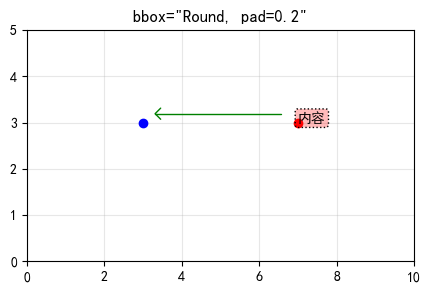

In [310]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

xy=(3, 3)
xytext = (7, 3)
# 创建基础图形
plt.figure(figsize=(5, 3))

plt.xlim(0, 10)
plt.ylim(0, 5)
plt.plot(xy[0], xy[1], "bo")
plt.plot(xytext[0], xytext[1], "ro")  # 开始点A
arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=0.0, armB=0.0, fraction=0.0, angle=0"
arrowprops["color"] = "green"
arrowprops["shrinkA"] = 10
arrowprops["shrinkB"] = 10
arrowprops["mutation_scale"] = 10
arrowprops["mutation_aspect"] = 2.0

# 边框属性
bbox = dict(
    boxstyle="Round, pad=0.2",
    mutation_scale=1.0,
    facecolor="#FF000044",
    # hatch="///",
    linestyle=":"
)

# 使用patchA和patchB连接两个圆形
plt.annotate('内容', xy=xy,  xytext=xytext, arrowprops=arrowprops, bbox=bbox)
plt.title('bbox="Round, pad=0.2"')
plt.grid(True, alpha=0.3)

plt.show()

- 代码说明：
    - 我们对其他bbox的boxstyle没有全部在代码中体现，后面在介绍Text对象的时候，会作为高级主题介绍。下面我们从官方文档截取的效果图

>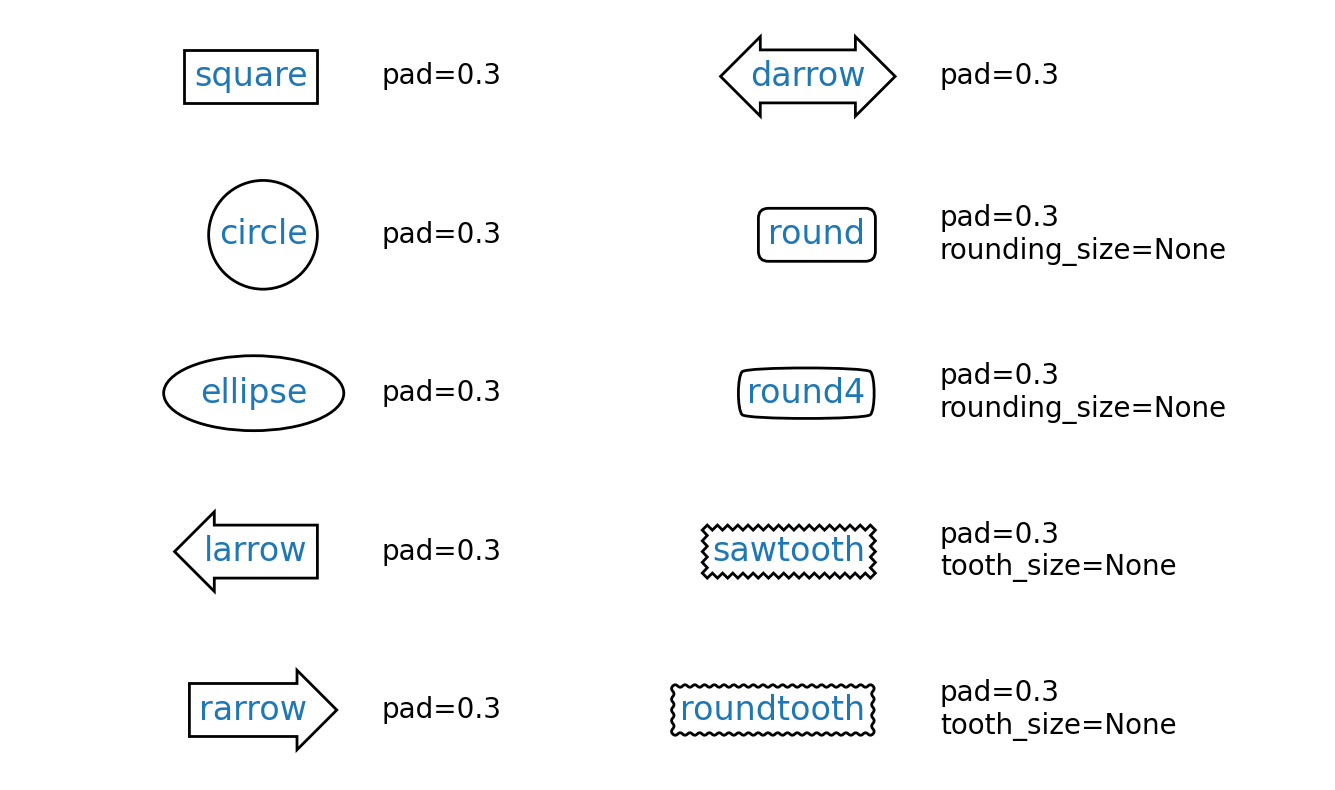

- 花式箭头中relpos参数的使用例子：
    - relpos:设置文本位置相对于箭头终点的偏移，坐标范围: (0,0) 到 (1,1)，表示相对位置。默认值(0.5, 0.5)

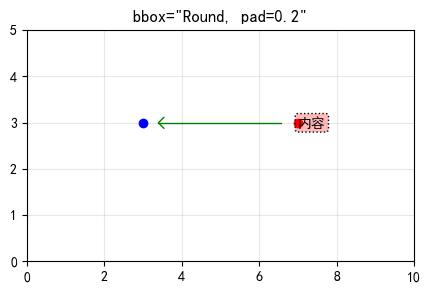

In [322]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

xy=(3, 3)
xytext = (7, 3)
# 创建基础图形
plt.figure(figsize=(5, 3))

plt.xlim(0, 10)
plt.ylim(0, 5)
plt.plot(xy[0], xy[1], "bo")
plt.plot(xytext[0], xytext[1], "ro")  # 开始点A
arrowprops = {}
arrowprops["arrowstyle"] = "->"
arrowprops["connectionstyle"] = "bar, armA=0.0, armB=0.0, fraction=0.0, angle=0"
arrowprops["color"] = "green"
arrowprops["shrinkA"] = 10
arrowprops["shrinkB"] = 10
arrowprops["mutation_scale"] = 10
arrowprops["mutation_aspect"] = 2.0
arrowprops["relpos"] = (0.5, 0.5)


# 边框属性
bbox = dict(
    boxstyle="Round, pad=0.2",
    mutation_scale=1.0,
    facecolor="#FF000044",
    # hatch="///",
    linestyle=":"
)

# 使用patchA和patchB连接两个圆形
plt.annotate('内容', xy=xy,  xytext=(7, 2.9), arrowprops=arrowprops, bbox=bbox)
plt.title('relpos参数 + xytext')
plt.grid(True, alpha=0.3)

plt.show()

- 代码说明：
    - 注意bbox的原点坐标是xytext，relpos控制箭头与bbox的关系，relpos的坐标是单位标准坐标系度量，而且是bbox的坐标系，设置relpos的值最好是在bbox的框内。

### (3) 箭头标注-arrow函数

- arrow函数负责绘制两个点之间的箭头，该函数不再鼓励使用，因为我们上面使用了annotate函数。官方文档鼓励使用空文本注释的annotate来替代。我们这里简单介绍下arrow函数的使用即可，该函数本身也比较简单：
    - 不鼓励使用arrow的原因是：因为不能保证箭头绘制合理。比如生成的箭头会受到轴纵横比和限制的影响，这可能会扭曲箭头。
    - 使用annotate替代的方式：`plt.annotate("", xytext=(0, 0), xy=(0.5, 0.5), arrowprops=dict(arrowstyle="->"))`

- arrow函数的原型定义与参数说明

```python
matplotlib.pyplot.arrow(
    x, y,    # 箭头开始位置
    dx, dy,  # 箭头的长度,dx在x轴的长度，dy是在dy的长度（箭头本质是在一个矩形内，x，y是矩形的左下角的点，dx，dy是矩形的宽高）
    **kwargs # 箭头与连接线的属性设置，以及Patch对象的属性
)
```

- 箭头与连接线的参数：
    - width：箭头连线的粗细，参数类型float，默认值0.001
    - length_includes_head：箭头的长度是否包含在箭头线总长中？参数类型是bool值，默认值是False。
    - head_width：箭头的宽度，默认值是箭头连线的3倍：`width*3`
    - head_length：箭头的长度，参数类型是float，是head_width的1.5倍：`1.5*head_width`
    - shape：控制箭头的完整性，取值{'full', 'left', 'right'}，表示{'完整箭头', '左半箭头', '右半箭头'}
    - overhang：控制箭头头部与箭头连线的重叠程度，用于调整箭头的视觉样式，参数类型是float，默认值是0，该值可以取负数，0与正数。
    - head_starts_at_zero：箭头是否从0开始，参数是bool，默认是False。

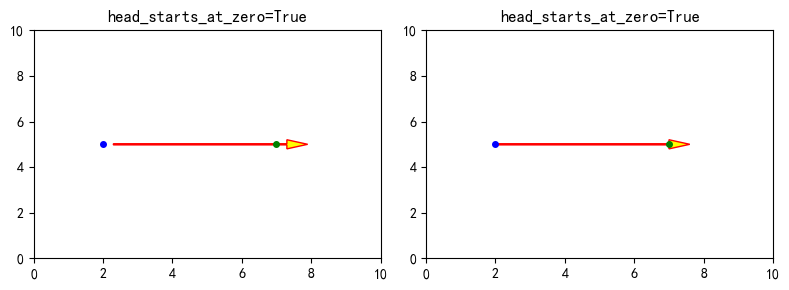

In [395]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.figure(figsize=(8, 3))

# -----------------------------
plt.subplot(121)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.plot(2, 5, 'bo', markersize=4, label='起点')
plt.plot(7, 5, 'go', markersize=4, label='终点')
plt.arrow(
    2, 5, 
    5, 0, 
    width=0.05,
    length_includes_head=False,
    head_width=0.4,
    head_length=0.6,
    shape="full",
    overhang=0.0,
    head_starts_at_zero=True,
    facecolor="yellow",
    edgecolor='red',
    linewidth=1
)
plt.title("head_starts_at_zero=True")
# --------------------------------
plt.subplot(122)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.plot(2, 5, 'bo', markersize=4, label='起点')
plt.plot(7, 5, 'go', markersize=4, label='终点')
plt.arrow(
    2, 5, 
    5, 0, 
    width=0.05,
    length_includes_head=False,
    head_width=0.4,
    head_length=0.6,
    shape="full",
    overhang=0.0,
    head_starts_at_zero=False,
    facecolor="yellow",
    edgecolor='red',
    linewidth=1
)
plt.title("head_starts_at_zero=True")

plt.tight_layout()
plt.show()

- 代码说明：
    - 在代码中的参数作用比较明确，但是其中取值的单位是以坐标系为单位，可以尝试修改`plt.xlim(0, 10)`与`plt.ylim(0, 10)`，可以感受箭头随着坐标系的单位改变而导致的问题。
    - 大家可以在使用，因为坐标单位的不一样，导致在设置值的时候，需要根据坐标系调整，这种在移植的时候比较麻烦。

### (4) 图例标注-legend/figlegend函数

- 图例标注在图表总是比较常用的。图表标注负责图表中不同元素含义的说明，其作用有：
    - 标识数据元素：帮助区分图表中的不同数据系列或类别的元素。
    - 提高可读性：让观众快速理解图表中各种颜色、线型或标记代表的含义。
    - 增强专业性：规范的图例是专业图表的基本要素。

- 在图表中，图例标注分两个场景：
    - 在Figure中绘制，这个所有Axes可以共享。由figlegend函数负责。
    - 在Axes中绘制，只标注所在Axes中的数据系列或者分类元素，由legend函数负责。

- legend函数与figlegend函数的原型定义与参数说明：

```python
matplotlib.pyplot.legend(
    *args,    # 采用变长参数来设置相关参数（位置参数）
    **kwargs) # 采用关键字参数来设置相关参数（关键字参数）

matplotlib.pyplot.figlegend(
    *args, 
    **kwargs
)

函数返回Legend对象。
```

- 两个函数的参数的推荐使用方式：

```python
legend()    # 自动绘制图例（所以）
legend(handles, labels)  # 对指定的数据元素进行图例处理，并使用指定的标签。
legend(handles=handles)  # 对指定的数据元素进行图例处理，直接使用数据元素的label属性作为标签（如果有的话，没有则使用None或者""）。
legend(labels) # 直接对对应标签的数据元素进行图例处理。

figlegend()
figlegend(handles, labels)
figlegend(handles=handles)
figlegend(labels)
```

- legend/figlegend函数的基本使用
    - 基本使用主要就是设置需要显示图例的数据元素：handles与每个图例对应的标识标签labels。
    - handles是数据元素数组或者列表。labels是字符串数组，handles与labels的长度一样，其中的数据元素与标签对应。

- 基础图例使用例子
    - legend函数（在Axes中显示图例）
    - 提示：变长参数只能使用位置参数。但是`figlegend(handles=handles)`其中必须使用关键字参数，这个参数形式来自`**kwargs`。

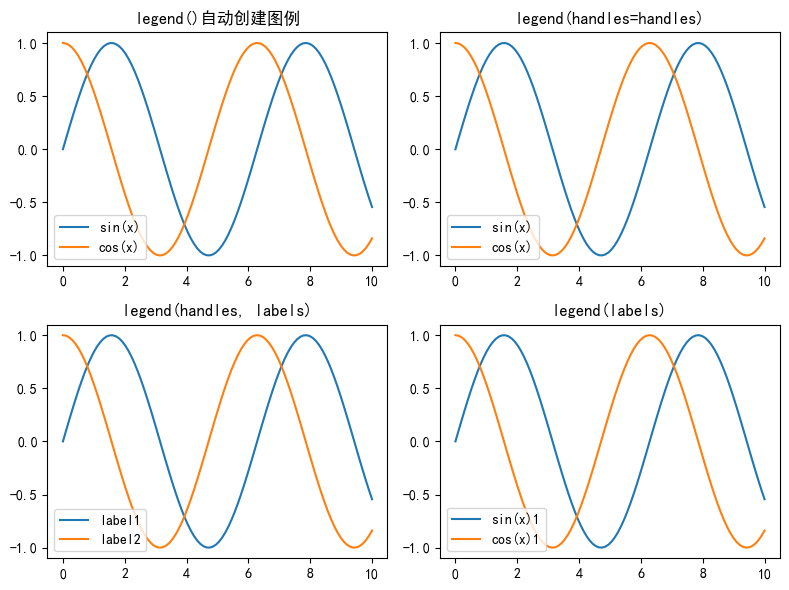

In [12]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(8,6))
#####################################
plt.subplot(221)
# 绘制图形并添加标签
plt.plot(x, y1, label='sin(x)')
plt.plot(x, y2, label='cos(x)')
# 自动创建图例
plt.legend()
plt.title("legend()自动创建图例")
#####################################
plt.subplot(222)
# 绘制图形并添加标签
h1, = plt.plot(x, y1, label='sin(x)')
[h2] = plt.plot(x, y2, label='cos(x)')
# 使用数据元素创建图例
plt.legend(handles=[h1, h2])
plt.title("legend(handles=handles)")
#####################################
plt.subplot(223)
# 绘制图形并添加标签
h3, = plt.plot(x, y1, label='sin(x)')
h4, = plt.plot(x, y2, label='cos(x)')
# 使用数据元素创建图例，并设置标签
plt.legend([h1, h2], ["label1", "label2"])   # 不需要使用关键字参数
plt.title("legend(handles, labels)")
#####################################
plt.subplot(224)
# 绘制图形并添加标签
h3 = plt.plot(x, y1, label='sin(x)')
h4 = plt.plot(x, y2, label='cos(x)')
# 使用标签创建图例
plt.legend(["sin(x)-1", "cos(x)-1"])
plt.title("legend(labels)")
#####################################

plt.tight_layout()
plt.show()

- 代码说明：
    - `h1, = plt.plot(x, y1, label='sin(x)')`与`[h2] = plt.plot(x, y2, label='cos(x)')`代码中，因为plot函数返回的是Line2D对象数组，我们采用了两种方式解包(unpack)。
    - 代码中演示了legend4中最基本的输出图例的方式。
        - 其中有三个是来自`**args`参数。
        - 其中`plt.legend(handles=[h1, h2])`参数是来自`**kwargs`。
    - 注意：代码中最后图表中，标签可以与数据元素的标签不同，legend会按照输出顺序与指定的标签对应。
        - `h3 = plt.plot(x, y1, label='sin(x)')`
        - `h4 = plt.plot(x, y2, label='cos(x)')`
        - `plt.legend(["sin(x)-1", "cos(x)-1"])`  # 标签与上面plot的标签可以不同，legend会自动案顺序对应，这种方式简洁，但不可控（不推荐使用）。

- 使用loc参数控制图例的位置：
    - loc参数的类型可以是：
        - str：字符串类型可以取值
            - 'upper left', 'upper right', 'lower left', 'lower right'：图例显示在四个角的位置。
            - 'upper center', 'lower center', 'center left', 'center right'：图例显示在四个边的中间。
            - 'center'：图例显示在图表正中。
            - 'best'：图例显示在最合适的位置，就是上面的9个位置中，最好的位置，所谓最好位置就是图例与图表中数据元素重叠最少。该参数在图表元素比较多的情况下，速度会特别慢，建议强制指定前面9个位置最好。
        - (float, float),指定绝对位置。
            - 指定绝对位置后，参数bbox_to_anchor就失效。 
        - 默认值是str类型，由环境变量 `rcParams["legend.loc"]`设置，一般是'best'。
    - loc参数中的字符串为了向后兼容，其中字符串可以简写：
        - 'center right'简写为'right'
        - 字符串也可以使用顺序编码替代:
            - 'best' (Axes only)：0
            - 'upper right'：1
            - 'upper left'：2
            - 'lower left'：3
            - 'lower right'：4
            - 'right'：5
            - 'center left'：6
            - 'center right'：7
            - 'lower center'：8
            - 'upper center'：9
            - 'center' ：10

- 使用loc设置图例位置的例子：

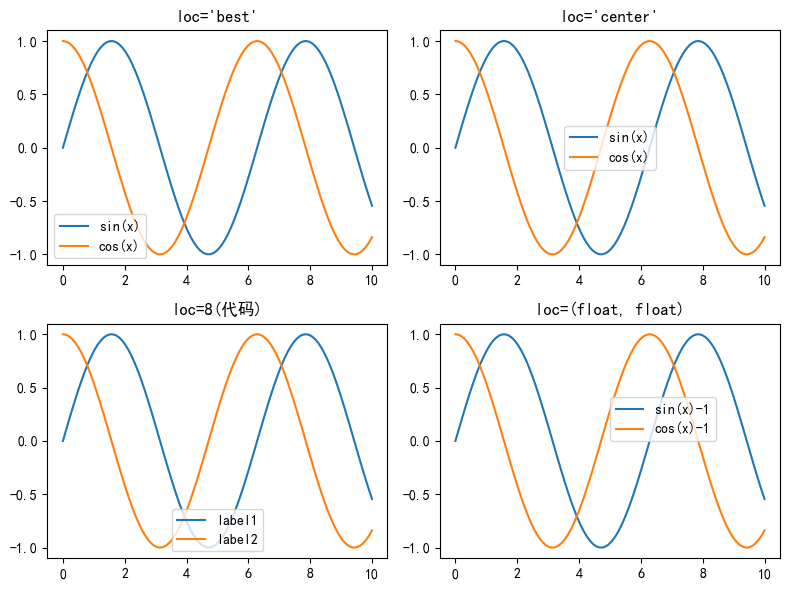

In [16]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(8,6))
#####################################
plt.subplot(221)
# 绘制图形并添加标签
plt.plot(x, y1, label='sin(x)')
plt.plot(x, y2, label='cos(x)')
# 自动创建图例
plt.legend(loc="best")
plt.title("loc='best'")    # 使用默认值best
#####################################
plt.subplot(222)
# 绘制图形并添加标签
h1, = plt.plot(x, y1, label='sin(x)')
[h2] = plt.plot(x, y2, label='cos(x)')
# 使用数据元素创建图例
plt.legend(handles=[h1, h2], loc="center")   # 使用字符串
plt.title("loc='center'")
#####################################
plt.subplot(223)
# 绘制图形并添加标签
h3, = plt.plot(x, y1, label='sin(x)')
h4, = plt.plot(x, y2, label='cos(x)')
# 使用数据元素创建图例，并设置标签
plt.legend([h1, h2], ["label1", "label2"], loc=8)   # 使用代码
plt.title("loc=8(代码)")
#####################################
plt.subplot(224)
# 绘制图形并添加标签
h3 = plt.plot(x, y1, label='sin(x)')
h4 = plt.plot(x, y2, label='cos(x)')
# 使用标签创建图例
plt.legend(["sin(x)-1", "cos(x)-1"], loc=(0.5, 0.5))
plt.title("loc=(float, float)")
#####################################

plt.tight_layout()
plt.show()

- 代码说明：
    - 上面代码中需要说明的是：`plt.legend(["sin(x)-1", "cos(x)-1"], loc=(0.5, 0.5))`其中位置坐标的单位是`[0,1]`，使用的是标准坐标系。关于坐标系，我们也会在后面用专门主题解释。

- 使用bbox_to_anchor参数配合loc控制图例的位置。还参数类型可以是：
    - BboxBase对象：比如Bbox对象也是BboxBase对象。`matplotlib.transforms.Bbox(points, **kwargs)`
        - points的格式：`[[xmin, ymin], [xmax, ymax]]`
    - (float, float)：表示位置(x, y)
    - (float, float, float, float)：表示位置为区域(x, y, width, height)
    - 说明：
        - BboxBase对象与(float, float, float, float)的作用一样。但是(float, float, float, float)更加简洁。
    - bbox_to_anchor为 BboxBase对象或者(float, float, float, float)，这图例绘制在这个指定的区域。

- BboxBase对象的类关系结构：

>![BboxBase.svg](BboxBase.svg)

- Bbox也是BBoxBase对象。
    - Bbox的构造器的参数格式：`[[xmin, ymin], [xmax, ymax]]`
    - Bbox的坐标系是标准坐标系：`[0,  1]`

- bbox_to_anchor参数的使用例子：

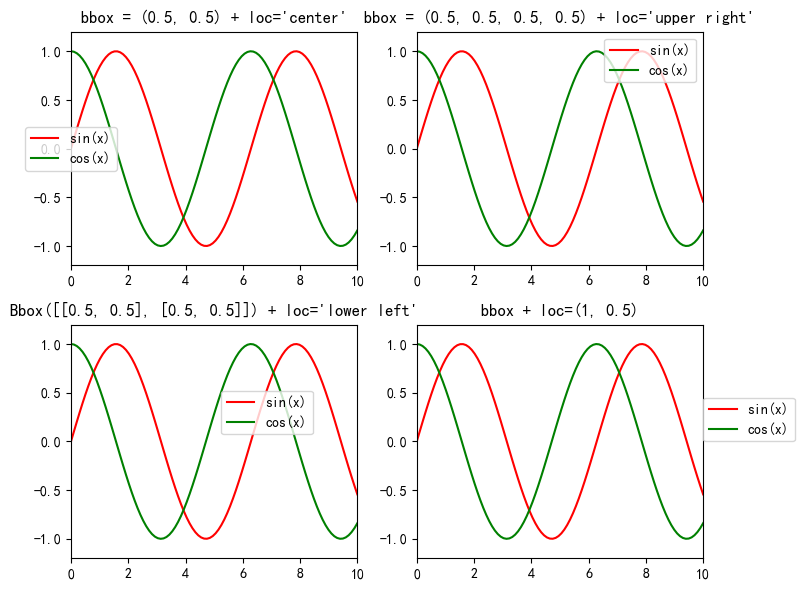

In [41]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(8, 6))
#####################################
plt.subplot(221)
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")
# 自动创建图例
bbox = (0, 0.5)  # 图例loc指定的位置与bbox重叠。
plt.legend(loc="center", bbox_to_anchor=bbox)
plt.title("bbox = (0.5, 0.5) + loc='center'")    # 使用默认值best
#####################################
plt.subplot(222)
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")

bbox = (0.5, 0.5, 0.5, 0.5)
plt.legend(loc="upper right", bbox_to_anchor=bbox)
plt.title("bbox = (0.5, 0.5, 0.5, 0.5) + loc='upper right'")    # 使用默认值best
#####################################
plt.subplot(223)
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")

from matplotlib.transforms import Bbox
bbox = Bbox([[0.5, 0.5], [0.5, 0.5]])
plt.legend(loc="lower left", bbox_to_anchor=bbox)
plt.title("Bbox([[0.5, 0.5], [0.5, 0.5]]) + loc='lower left'")    # 使用默认值best
#####################################
plt.subplot(224)
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")

bbox = (0.5, 0.5, 0.5, 0.5)
# from matplotlib.transforms import Bbox
# bbox = Bbox([[0.5, 0.5], [1, 1]])
plt.legend(loc=(1, 0), bbox_to_anchor=bbox)
plt.title("bbox + loc=(1, 0.5)")    # 使用默认值best
#####################################

plt.tight_layout()
plt.show()

- 代码说明：
    - 当`loc=(x, y)`的时候，`bbox_to_anchor`参数无效。
    - 当`bbox_to_anchor=(x, y)`的时候，legend的`loc`在`bbox_to_anchor`位置。
    - 当`bbox_to_anchor=(x, y, widht, height)`或者`bbox_to_anchor=Bbox([[xmin, ymin], [xmax. ymax]])`的时候，legend在bbox指定的区域定位。
    - 说明：
        - 可以使用bbox_transform参数指定bbox的坐标系，这里我们使用默认的坐标系即可：Axes.transAxes。

- 图例的列数与标题：
    - 参数ncols可以指定图例的列数
        - 参数类型是int，默认值是1.
        - 当我们需要的时候，可以指定图例的列数，尤其当图例很多的时候。
    - 参数title可以设置图例的标题：
        - 参数类型是字符串，默认是None
    - 参数title_fontproperties可以指定标题的属性。
        - 参数类型是FontProperties对象或者dict字典（字典的字段还是来自FontProperties对象的属性），字体属性基本的就6个。
        - 部分参数由环境变量设置`rcParams["legend.title_fontsize"]`。
        - 其中对数学公式的渲染采用的字体是扩展math_fontfamily，可以取值：'dejavusans', 'dejavuserif', 'stix', 'stixsans', 'cm'等
            - 'cm'： 使用经典的TeX Computer Modern字体，这是LaTeX的默认字体，数学显示效果非常好。
            - 'stix'： STIX字体，专门为科学和技术文档设计。
            - 'dejavusans'： DejaVu Sans字体，是Matplotlib的默认sans-serif字体。
    - title_fontsizeint参数：
        - 这个字体属性经常使用，就直接做成参数了。取值{'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}, 默认值由`rcParams["legend.title_fontsize"]`设置为None。
    - alignment设置图例标题的位置，取值{'center', 'left', 'right'}, 默认值是'center'。这个值也影响图例的对齐位置。

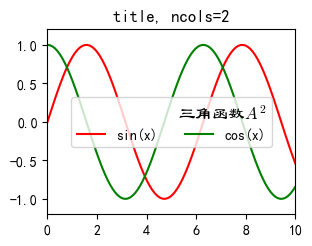

In [55]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(3.2, 2.4))

plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")

title_fontproperties = dict(
    family="LiSu", 
    size= 12,
    weight= 900,
    style="italic",  # 需要字体支持
    math_fontfamily="cm"
)
plt.legend(loc="center", ncols=2, title="三角函数$A^2$", title_fontproperties=title_fontproperties, alignment="right")
plt.title("title, ncols=2")    # 使用默认值best

plt.show()

 - 设置legend的外观修饰：
     - frameon：设置是否显示legend的边框，参数类型是bool，默认值True。参数可以由环境变量`rcParams["legend.frameon"]`设置。
     - fancybox：设置图例框的边角样式，参数类型bool，默认值True，参数可以由环境变量` rcParams["legend.fancybox"]`设置。True采用圆角。
     - shadow：设置是否绘制阴影，参数类型是bool，默认值是False。参数也可以由环境变量`rcParams["legend.shadow"]`设置。True会绘制阴影。
     - framealpha：设置legend的背景是否透明，参数类型是float(0-1之间的float值)，默认值是0.8。参数也可以由环境变量`rcParams["legend.framealpha"]`设置。如果shadow被设置，framealpha=None，这默认值0.8无效。
     - facecolor：设置legend的背景颜色，参数取值`inherit`，表示采用环境变量`rcParams["legend.facecolor"]`，环境变量的默认值是'white'，facecolor参数默认值是`inherit`。参数也可以直接指定一个颜色（标准的color值格式）
     - edgecolor：设置legend的边界颜色，也可以由环境变量`rcParams["legend.edgecolor"]`设置（设置值0.8）默认值，参数可以指定一个颜色color值。参数可以取值'inherit'，表示使用`rcParams["axes.edgecolor"]`的值，该值默认为'black'。


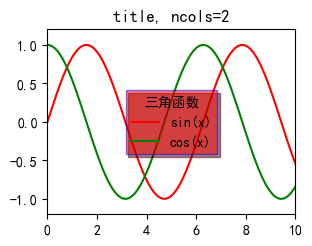

In [61]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(3.2, 2.4))

plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")

plt.legend(loc="center", ncols=1, title="三角函数",
           frameon=True, 
           fancybox=False, 
           shadow=True, 
           facecolor="red", 
           edgecolor="blue", 
           framealpha=0.5)
plt.title("title, ncols=2")    # 使用默认值best

plt.show()

- 代码说明：
    - 一般情况下，我们建议要么全部采用环境变量，要么才用参数显示设置。环境变量设置在统一风格方面是较好的选择方案。需要个性化的就由参数设置。在环境变量与参数同时设置的情况下，参数优先（这个遵循局部优先原则）
    - 注意：没有提供边界线宽度的设置参数。

- 控制legend中标签与图例内容：
    - prop：设置图例内容中标签的字体属性
    - fontsize：把常用的字体大小单数使用该参数设置，参数类型是int或者取值{'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}。当指定prop参数的时候，该参数无效。
    - labelcolor：设置标签的颜色。也可以由`rcParams["legend.labelcolor"]`设置（None），如果该参数为None，则使用`rcParams["text.color"]`的默认值，该值为"black"。该参数可以设置一个颜色（所有标签一样的颜色）或者颜色列表（对应每个标签）。
        - labelcolor可以设置为"linecolor", "markerfacecolor", "markeredgecolor",这样可以让标签颜色与线条，marker及其边界颜色一样。
    - numpoints：设置图例显示的数量(Line2D的图例)。默认值为1，也可以由`rcParams["legend.numpoints"]`设置。
    - scatterpoints：设置图例显示的数量(PathCollection的图例)，默认值为1，也可以由`rcParams["legend.scatterpoints"]`设置。
    - scatteryoffsets：设置图例间的间距，参数是float数组，默认值是`[0.375, 0.5, 0.3125]`（相对间距），整个legend的高度标准化为1，下面为0，上面为1，如果想设置图例一样间距，则设置为0.5。
        - 注意这个偏移值是以标签文本的baseline为参照。对齐为0，最高为1.0。
    - markerscale：marker的缩放比例，默认值1，也可以由`rcParams["legend.markerscale"]`设置。
    - markerfirst：设置marker的绘制优先级，默认是True，表示marker绘制在标签的前面。
    - reverse ：设置图例的显示顺序，默认值是False，如果为True，图例的显示顺序与图表中数据元素的绘制顺序相反。

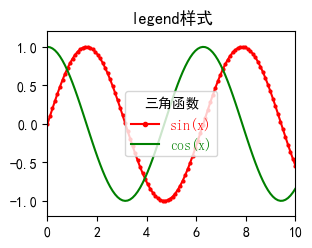

In [81]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(3.2, 2.4))

plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, marker=".", markersize=4, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")
prop = dict(
    family="LiSu",
    size=10,
    weight=900)

plt.legend(loc="center", ncols=1, title="三角函数",
           prop=prop,
           labelcolor="linecolor",   # ["yellow", "cyan"]
           numpoints=1,     # 当绘制的数量很多的情况，会有效果。
           scatterpoints=2,
           scatteryoffsets=[0.5],
           markerscale=1.5,
           markerfirst=True,
           reverse=False)
plt.title("legend样式")    # 使用默认值best

plt.show()

- 代码说明：
    - 代码中没有通过对比来体验每一个属性的作用。我们在下面对每个参数分开对比体验。

- labelcolor的体验

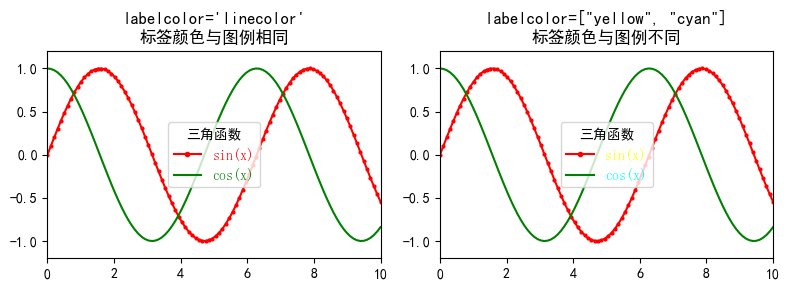

In [84]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, marker=".", markersize=4, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")
prop = dict(
    family="LiSu",
    size=10,
    weight=900)

plt.legend(loc="center", ncols=1, title="三角函数",
           prop=prop,
           labelcolor="linecolor",   # ["yellow", "cyan"]
           numpoints=1,     # 当绘制的数量很多的情况，会有效果。
           scatterpoints=2,
           scatteryoffsets=[0.5],
           markerscale=1.5,
           markerfirst=True,
           reverse=False)
plt.title("labelcolor='linecolor'\n标签颜色与图例相同") 

#############################################
plt.subplot(122)
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, marker=".", markersize=4, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")
prop = dict(
    family="LiSu",
    size=10,
    weight=900)

plt.legend(loc="center", ncols=1, title="三角函数",
           prop=prop,
           labelcolor=["yellow", "cyan"],
           numpoints=1,     # 当绘制的数量很多的情况，会有效果。
           scatterpoints=2,
           scatteryoffsets=[0.5],
           markerscale=1.5,
           markerfirst=True,
           reverse=False)
plt.title('labelcolor=["yellow", "cyan"]\n标签颜色与图例不同') 

plt.tight_layout()
plt.show()

- 代码说明：
    - `labelcolor="linecolor"` 左边的标签颜色与图例颜色一样，分别是红色与绿色。
    - `labelcolor=["yellow", "cyan"]` 右边的标签颜色分别是黄色与翠色。

- numpoints的体验:

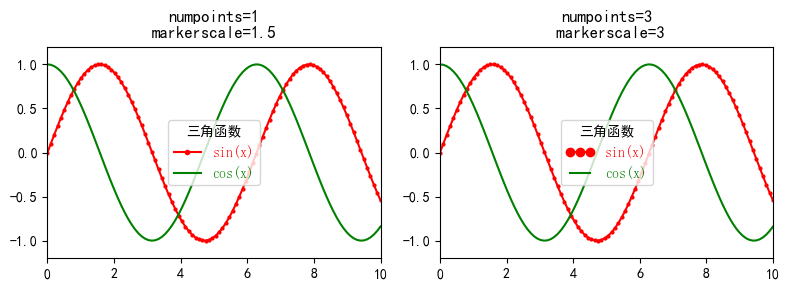

In [4]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成示例数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, marker=".", markersize=4, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")
prop = dict(
    family="LiSu",
    size=10,
    weight=900)

plt.legend(loc="center", ncols=1, title="三角函数",
           prop=prop,
           labelcolor="linecolor", 
           numpoints=1,     # 当绘制的数量很多的情况，会有效果。
           scatterpoints=2,
           scatteryoffsets=[0.5],
           markerscale=1.5,
           markerfirst=True,
           reverse=False)
plt.title("numpoints=1\nmarkerscale=1.5") 

#############################################
plt.subplot(122)
plt.xlim(0, 10)
plt.ylim(-1.2, 1.2)
# 绘制图形并添加标签
plt.plot(x, y1, marker=".", markersize=4, label='sin(x)', color="red")
plt.plot(x, y2, label='cos(x)', color="green")
prop = dict(
    family="LiSu",
    size=10,
    weight=900)

plt.legend(loc="center", ncols=1, title="三角函数",
           prop=prop,
           labelcolor="linecolor",
           numpoints=3,     # 当绘制的数量很多的情况，会有效果。
           scatterpoints=2,
           scatteryoffsets=[0.5],
           markerscale=3,
           markerfirst=True,
           reverse=False)
plt.title('numpoints=3\n markerscale=3') 

plt.tight_layout()
plt.show()

- 代码说明：
    - 注意左边图例中点的数量是1(numpoints=1)，右边图例中点的数量是3(numpoints=3)
    - `scatterpoints=2`, 也是与图形绘制的类型有关。

- scatteryoffsets参数的体验：

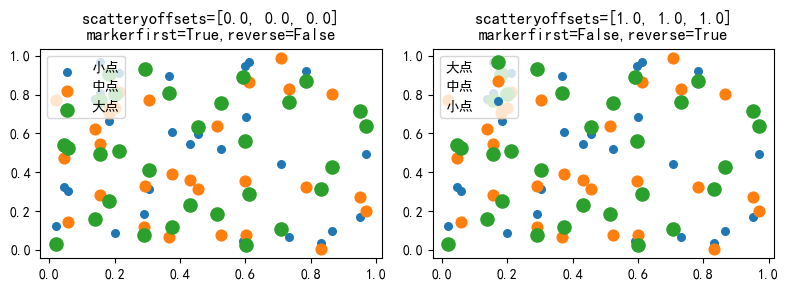

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建示例数据
np.random.seed(42)
x = np.random.rand(30)
y1 = np.random.rand(30)
y2 = np.random.rand(30)
y3 = np.random.rand(30)

plt.figure(figsize=(8, 3))  # 图表大点，看的效果更好

# 左图：=[0.0, 0.0, 0.0]
plt.subplot(121)
plt.scatter(x, y1, label='小点', s=30)
plt.scatter(x, y2, label='中点', s=60)
plt.scatter(x, y3, label='大点', s=90)
plt.legend(loc='upper left', 
           scatteryoffsets=[0.0, 0.0, 0.0],
           markerfirst=True,
           reverse=False)
plt.title('scatteryoffsets=[0.0, 0.0, 0.0]\nmarkerfirst=True,reverse=False')

# 右图：=[1.0, 1.0, 1.0]
plt.subplot(122)
plt.scatter(x, y1, label='小点', s=30)
plt.scatter(x, y2, label='中点', s=60)
plt.scatter(x, y3, label='大点', s=90)
plt.legend(loc='upper left', 
           scatteryoffsets=[1.0, 1.0, 1.0],
           markerfirst=False,
           reverse=True)
plt.title('scatteryoffsets=[1.0, 1.0, 1.0]\nmarkerfirst=False,reverse=True')

plt.tight_layout()
plt.show()

- 代码说明：
    - 大家对比左右图，看看图例点与标签文本的水平方向中线是否对齐。
    - 所以正常情况下，都去对齐高度是居中，既0.5。
    - 在该例子我们还对比了markerfirst与reverse。

- legend内容布局相关参数
    - borderpad：legend边界的空白，单位为字体大小。默认值0.4。可以由环境变量设置：`rcParams["legend.borderpad"]`
    - labelspacing：每个图例之间的间距，单位为字体大小。默认值0.5。可以由环境变量设置：`rcParams["legend.labelspacing"]`
    - handlelength：每个图例的长度，单位为字体大小。默认值2.0。可以由环境变量设置：`rcParams["legend.handlelength"]`
    - handleheight：每个图例的高度，单位为字体大小，默认值0.7。可以由环境变量设置：`rcParams["legend.handleheight"]`
    - handletextpad：每个图例与标签文本之间的间距，单位为字体大小，默认值0.8。可以由环境变量设置：`rcParams["legend.handletextpad"]`
    - borderaxespad：legend到坐标轴之间的间距，单位为字体大小，默认值0.5。可以由环境变量设置：`rcParams["legend.borderaxespad"]`
    - columnspacing：如果lgend是多列，则该参数设置列之间的间距，单位是字体大小，默认值2.0。可以由环境变量设置：`rcParams["legend.columnspacing"]`
    - handler_map：定制定义每个图例在legend中的显示特殊图例与样式。
    - draggable：legend可以拖动。

- legend内容与布局相关的参数意义比较明确，我们不详细介绍，对handler_map我们通过例子代码来说明。
    - 在matplotlib中对所有图例的处理都提供了基本的通用实现，比如：
    - HandlerBase
    - HandlerCircleCollection
    - HandlerErrorbar
    - HandlerLine2D
    - HandlerLine2DCompound
    - HandlerLineCollection
    - HandlerNpoints
    - HandlerNpointsYoffsets
    - HandlerPatch
    - HandlerPathCollection
    - HandlerPolyCollection
    - HandlerRegularPolyCollection
    - HandlerStem
    - HandlerStepPatch
    - HandlerTuple

- 图例内容布局参数的使用例子 - 列数与列宽设置

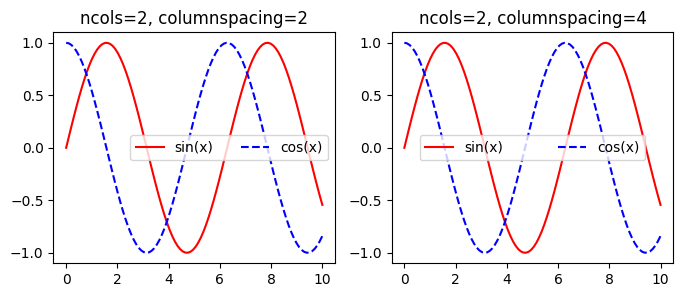

In [17]:
%matplotlib inline
# %matplotlib qt
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D

# 创建数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(8, 3))
# 列与列宽
plt.subplot(121)
line1, = plt.plot(x, y1, 'r-',  label='sin(x)')
line2, = plt.plot(x, y2, 'b--', label='cos(x)')
plt.legend(ncols=2, columnspacing=2)
plt.title("ncols=2, columnspacing=2")
# 对比
plt.subplot(122)
line1, = plt.plot(x, y1, 'r-',  label='sin(x)')
line2, = plt.plot(x, y2, 'b--', label='cos(x)')
plt.legend(ncols=2, columnspacing=4)
plt.title("ncols=2, columnspacing=4")

plt.show()

- 代码说明：
    - 这个例子中说明了ncols与columnspacing参数的功能，一个控制图例的列数，一个控制每列的之间的宽度。

- - 图例内容布局参数的使用例子 - 间距与高宽设置

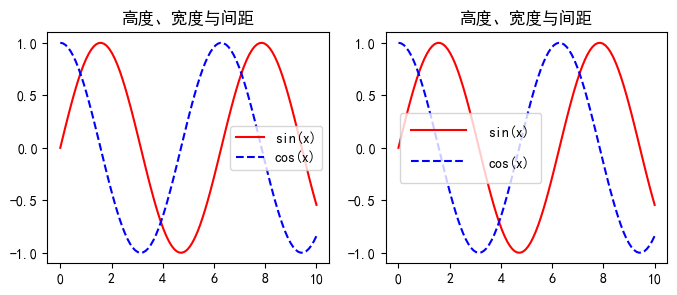

In [19]:
%matplotlib inline
# %matplotlib qt
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(8, 3))
# 列与列宽
plt.subplot(121)
line1, = plt.plot(x, y1, 'r-',  label='sin(x)')
line2, = plt.plot(x, y2, 'b--', label='cos(x)')
plt.legend(
    borderpad=0.4,
    labelspacing=0.5,
    handlelength=2.0,
    handleheight=0.7,
    handletextpad=0.8,
    borderaxespad=0.5
)
plt.title("高度、宽度与间距")
# 对比
plt.subplot(122)
line1, = plt.plot(x, y1, 'r-',  label='sin(x)')
line2, = plt.plot(x, y2, 'b--', label='cos(x)')
plt.legend(
    borderpad=0.8,
    labelspacing=1.0,
    handlelength=4.0,
    handleheight=1.5,
    handletextpad=1.6,
    borderaxespad=1.0
)
plt.title("高度、宽度与间距")

plt.show()


- 代码说明：
    - 代码中，左边图表采用默认值，右边图表采用了加倍的值。可以根据每个参数实际控制的值，进行对比。

- legend内容与布局相关的参数意义比较明确，我们不详细介绍，对handler_map我们通过例子代码来说明。
    - 在matplotlib中对所有图例的处理都提供了基本的通用实现，比如：
    - HandlerBase
    - HandlerCircleCollection
    - HandlerErrorbar
    - HandlerLine2D
    - HandlerLine2DCompound
    - HandlerLineCollection
    - HandlerNpoints
    - HandlerNpointsYoffsets
    - HandlerPatch
    - HandlerPathCollection
    - HandlerPolyCollection
    - HandlerRegularPolyCollection
    - HandlerStem
    - HandlerStepPatch
    - HandlerTuple

- 下面是直接使用内置handler的例子

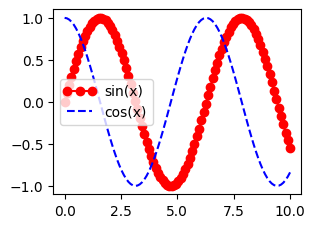

In [15]:
%matplotlib inline
# %matplotlib qt
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D

# 创建数据
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(3.2, 2.4))
# 绘制两条线
line1, = plt.plot(x, y1, 'r-', marker="o", label='sin(x)')
line2, = plt.plot(x, y2, 'b--', label='cos(x)')

# 使用handler_map自定义图例处理
plt.legend(
    handler_map={
        Line2D: HandlerLine2D(numpoints=3, marker_pad=0.1)
    },
    draggable=True
)

plt.show()

- 代码说明：
    - `plt.legend(handler_map={Line2D: HandlerLine2D(numpoints=1)})`代码说明需要处理的图例类型是Line2D，并且由HandlerLine2D对象负责图例对象的创建。
    - `draggable=True`的效果需要再GUI模式下可以体验，可以应用鼠标进行拖拽，这可以避免legend盖住可视化数据图形的情况。
    - 其实根据需要，还可以定制化每个类型的图例，在下面图例的高级主题中介绍。

### (5) 表格绘制-table函数

- table函数负责在Axes中添加表格，可以方便地将数据以表格形式展示在图表中，可以图表与表格结合进行数据可视化分析。

- table函数的原型定义与参数说明：


```python
matplotlib.pyplot.table(
    cellText=None, # 2D字符串数组或者pandas.DataFrame，包含表格单元格的文本内容过长会导致文本超出单元格边界。
    cellColours=None,  # 2D颜色数组，每个单元格的颜色。
    cellLoc='right', # 单元格中文本的对齐方式，取值{'right', 'center', 'left'}，默认值是right。
    colWidths=None, # 指定每列的宽度，参数类型是float数组。默认列宽是1/ncols
    rowLabels=None,  # 行标题文本，参数类型是字符串数组。
    rowColours=None, # 行标题的背景颜色。参数类型是颜色数组。
    rowLoc='left', # 行标题文本对齐方式，取值{'left', 'center', 'right'}，默认值是right。
    colLabels=None, # 列标题文本，参数类型是字符串数组
    colColours=None, # 列标题的背景颜色，参数类型是颜色数组。
    colLoc='center',  # 列标题的对齐方式，取值{'center', 'left', 'right'}，默认是right。
    loc='bottom',  # 表格在图表中的位置，，参数取值为 {'best': 0, 'bottom': 17, 'bottom left': 12, 'bottom right': 13, 'center': 9, 'center left': 5, 'center right': 6, 'left': 15, 'lower center': 7, 'lower left': 3, 'lower right': 4, 'right': 14, 'top': 16, 'top left': 11, 'top right': 10, 'upper center': 8, 'upper left': 2, 'upper right': 1}等。
    bbox=None,  # 指定表格的精确位置和大小，参数类型Bbox对象或者[xmin, ymin, width, height]格式。
    edges='closed', # 控制表格边框显示，取值{'closed', 'open', 'horizontal', 'vertical'} 或者 'BRTL'的子字符串。
    **kwargs)  # 来自Table对象的属性设置。
```

函数返回Table对象。有的属性无法通过参数来设置，只能通过Table对象来设置，比如表格的大小，或者某个单元格的二次属性调整等。

- table函数数据相关参数（单元格）的使用例子：
    - cellText: 2D字符串数组或者pandas.DataFrame，包含表格单元格的文本内容过长会导致文本超出单元格边界。
    - cellColours: 2D颜色数组，指定每个单元格的背景颜色
    - cellLoc: 单元格中文本的对齐方式，取值{'right', 'center', 'left'}，默认值是right。 

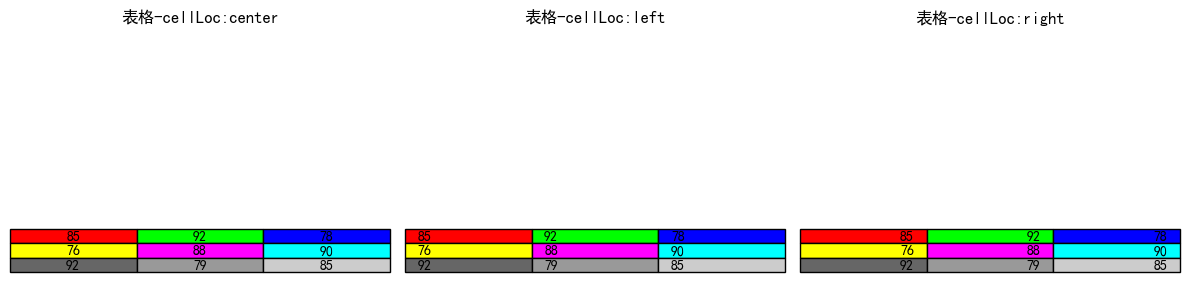

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
# 示例数据
cellText = [
    [85, 92, 78],
    [76, 88, 90],
    [92, 79, 85]
]
cellColours = [
    [(1, 0, 0), (0, 1, 0), (0, 0, 1)],
    [(1, 1, 0), (1, 0, 1), (0, 1, 1)],
    [(0.4, 0.4, 0.4), (0.6, 0.6, 0.6), (0.8, 0.8, 0.8)]
]

# 创建图表
plt.figure(figsize=(12, 3))

# 创建表格 - 1  **********************************
plt.subplot(131)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='center',
)
plt.title('表格-cellLoc:center')
plt.axis("off")
# 创建表格 - 2  **********************************
plt.subplot(132)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='left',
)
plt.title('表格-cellLoc:left')
plt.axis("off")
# 创建表格 - 3  **********************************
plt.subplot(133)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='right',
)

plt.title('表格-cellLoc:right')
plt.axis("off")

plt.tight_layout()
plt.show()

- 代码说明：
    - 表格默认的位置是在坐标系下面。
    - `plt.axis("off")`代码可以关闭坐标轴显示。后面还是在pyplot的Axis的配置中介绍。

- 表格在坐标系中位置与布局参数
    - loc：表格在图表中的位置
    - colWidths：指定每列的宽度
    - bbox: 指定表格的精确位置和大小

- 表格位置说明:
    - 表格的位置loc是通过预定义的代码来设置：
        - 'best': 0,
        - 'bottom': 17,
        - 'bottom left': 12,
        - 'bottom right': 13,
        - 'center': 9,
        - 'center left': 5,
        - 'center right': 6,
        - 'left': 15,
        - 'lower center': 7,
        - 'lower left': 3,
        - 'lower right': 4,
        - 'right': 14,
        - 'top': 16,
        - 'top left': 11,
        - 'top right': 10,
        - 'upper center': 8,
        - 'upper left': 2,
        - 'upper right': 1}

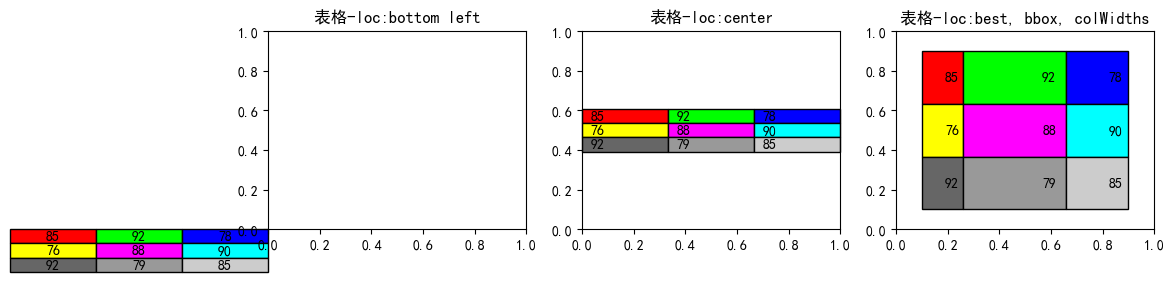

In [50]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
# 示例数据
cellText = [
    [85, 92, 78],
    [76, 88, 90],
    [92, 79, 85]
]
cellColours = [
    [(1, 0, 0), (0, 1, 0), (0, 0, 1)],
    [(1, 1, 0), (1, 0, 1), (0, 1, 1)],
    [(0.4, 0.4, 0.4), (0.6, 0.6, 0.6), (0.8, 0.8, 0.8)]
]

# 创建图表
plt.figure(figsize=(12, 3))

# 创建表格 - 1  **********************************
plt.subplot(131)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='center',
    loc=12   # "bottom left"
)
plt.title('表格-loc:bottom left')
# plt.axis("off")
# 创建表格 - 2  **********************************
plt.subplot(132)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='left',
    loc="center"  # 9
)
plt.title('表格-loc:center')
# plt.axis("off")
# 创建表格 - 3  **********************************
plt.subplot(133)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='right',
    loc="best",   # 0
    colWidths=[0.2, 0.5, 0.3],
    bbox=[0.1, 0.1, 0.8, 0.8]
)

plt.title('表格-loc:best, bbox, colWidths')
# plt.axis("off")

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们在使用loc参数的时候，既可以使用代码（比如：0），也课时使用字符串（比如："best"）
    - loc参数控制的是表格在坐标系中的方位（不是特别精确）
    - 其中colWidths参数的单位是坐标系单位。我们在代码中使用的是默认的单位坐标系。
    - bbox参数可以指定表格的显示区域，与坐标系中的精确位置。bbox在我们实际运行效果中，比loc的优先。

- 表格的行相关参数的使用例子：
    - rowLabels: 行标题文本（就是列头），参数类型是字符串数组，每个行的列头字符串。
    - rowColours: 行标题的背景颜色。只影响列头。是颜色数组，与列头数组一样长。
    - rowLoc: 行标题文本对齐方式，取值{'left', 'center', 'right'}

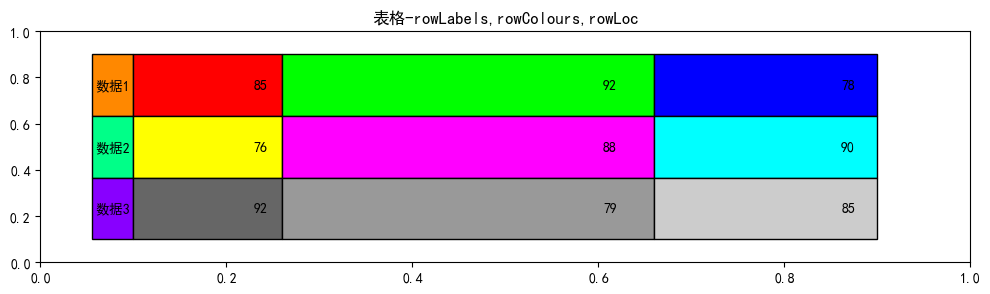

In [54]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
# 示例数据
cellText = [
    [85, 92, 78],
    [76, 88, 90],
    [92, 79, 85]
]
cellColours = [
    [(1, 0, 0), (0, 1, 0), (0, 0, 1)],
    [(1, 1, 0), (1, 0, 1), (0, 1, 1)],
    [(0.4, 0.4, 0.4), (0.6, 0.6, 0.6), (0.8, 0.8, 0.8)]
]
rowLabels = ["数据1", "数据2", "数据3"]
rowColours = ["#FF8800", "#00FF88", "#8800FF"]
rowLoc = "center"
# 创建图表
plt.figure(figsize=(12, 3))

table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='right',
    loc="best",   # 0
    colWidths=[0.2, 0.5, 0.3],
    bbox=[0.1, 0.1, 0.8, 0.8],
    rowLabels=rowLabels,
    rowColours=rowColours,
    rowLoc=rowLoc
)

plt.title('表格-rowLabels,rowColours,rowLoc')

plt.show()

- 代码说明：
    - 代码运行效果可以看出来的表格的loc定位不包含列头。
    - 一般在设计的时候，建议把行头的数据设计到单元格数据中去。

- 表格的列相关的参数使用例子：
    - colLabels:字段标签（列头）文本
    - colColours: 列标题的背景颜色
    - colLoc: 列标题文本对齐方式

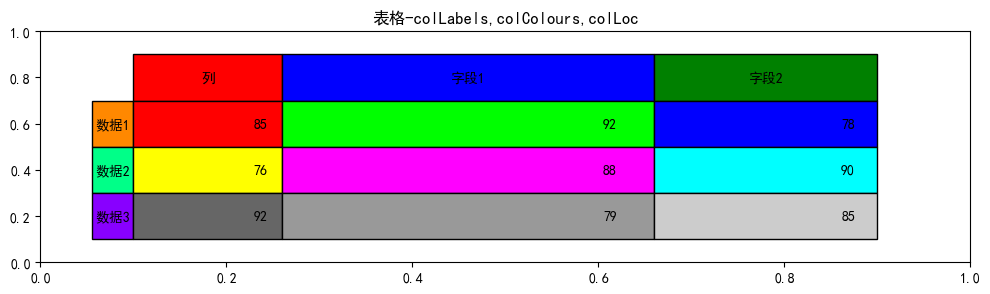

In [55]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
# 示例数据
cellText = [
    [85, 92, 78],
    [76, 88, 90],
    [92, 79, 85]
]
cellColours = [
    [(1, 0, 0), (0, 1, 0), (0, 0, 1)],
    [(1, 1, 0), (1, 0, 1), (0, 1, 1)],
    [(0.4, 0.4, 0.4), (0.6, 0.6, 0.6), (0.8, 0.8, 0.8)]
]
rowLabels = ["数据1", "数据2", "数据3"]
rowColours = ["#FF8800", "#00FF88", "#8800FF"]
rowLoc = "center"

colLabels = [ "字段1", "字段2", "字段3"]
colColours = ["red", "blue", "green"]
colLoc = "center"

# 创建图表
plt.figure(figsize=(12, 3))

table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='right',
    loc="best",   # 0
    colWidths=[0.2, 0.5, 0.3],
    bbox=[0.1, 0.1, 0.8, 0.8],
    rowLabels=rowLabels,
    rowColours=rowColours,
    rowLoc=rowLoc,
    colLabels=colLabels,
    colColours=colColours,
    colLoc=colLoc,
)

plt.title('表格-colLabels,colColours,colLoc')

plt.show()

- 代码说明：
    - 从代码运行效果，我们可以看出来，表头的高宽是包含在表格的bbox设置区域的，但是行头不包含在内。

- 表格的变量参数
    - edges: 控制表格边框显示，取值{'closed', 'open', 'horizontal', 'vertical'} 或者'BRTL'的子字符串。

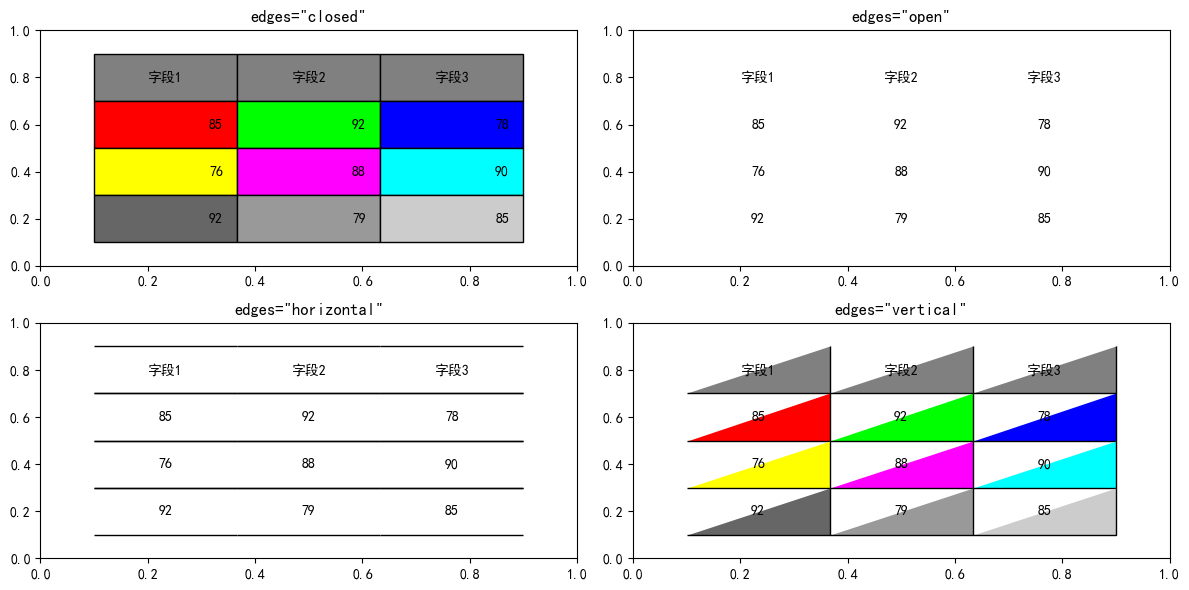

In [75]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
# 示例数据
cellText = [
    [85, 92, 78],
    [76, 88, 90],
    [92, 79, 85]
]
cellColours = [
    [(1, 0, 0), (0, 1, 0), (0, 0, 1)],
    [(1, 1, 0), (1, 0, 1), (0, 1, 1)],
    [(0.4, 0.4, 0.4), (0.6, 0.6, 0.6), (0.8, 0.8, 0.8)]
]
colLabels = [ "字段1", "字段2", "字段3"]
colColours = ["gray", "gray", "gray"]
colLoc = "center"


plt.figure(figsize=(12, 6))
# 图表边界：------------close
plt.subplot(221)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='right',
    bbox=[0.1, 0.1, 0.8, 0.8],
    colLabels=colLabels,
    colColours=colColours,
    colLoc=colLoc,
    edges= "closed"
)
plt.title('edges="closed"')
# 图表边界：------------open
plt.subplot(222)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='center',
    bbox=[0.1, 0.1, 0.8, 0.8],
    colLabels=colLabels,
    colColours=colColours,
    colLoc=colLoc,
    edges= "open"
)
plt.title('edges="open"')
# 图表边界：------------horizontal
plt.subplot(223)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='center',
    bbox=[0.1, 0.1, 0.8, 0.8],
    colLabels=colLabels,
    colColours=colColours,
    colLoc=colLoc,
    edges= "horizontal"
)
plt.title('edges="horizontal"')
# 图表边界：------------vertical
plt.subplot(224)
table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='center',
    bbox=[0.1, 0.1, 0.8, 0.8],
    colLabels=colLabels,
    colColours=colColours,
    colLoc=colLoc,
    edges="BR"  # edges= "vertical",
)
plt.title('edges="vertical"')

plt.tight_layout()
plt.show()

- 代码说明：
    - 表格的边界样式只有在closed的时候，颜色才有效。其他情况无效。
    - edges参数取"BRTL"的子串包含任意1个字符，2个字符，3个字符与4个字符。子串可以是四个字母的随意组合。

- table函数表格中文本的字体设置：
    - table函数在 `**kwargs`中开放了Table对象的属性，Table对象属性中只有一个属性与字体有关：`fontsize`，不能设置字体，不能设置文本颜色等。
    - 如果需要设置文本字体与颜色，就需要通过Table对象获取Cell对象，通过Cell对象获取Text对象才能设置。下面简单举一个例子说明。

{(1, 0): <matplotlib.table.Cell object at 0x000002232661B890>, (1, 1): <matplotlib.table.Cell object at 0x000002232661B250>, (1, 2): <matplotlib.table.Cell object at 0x0000022326618410>, (2, 0): <matplotlib.table.Cell object at 0x000002232661A5D0>, (2, 1): <matplotlib.table.Cell object at 0x0000022326618E10>, (2, 2): <matplotlib.table.Cell object at 0x000002232661B110>, (3, 0): <matplotlib.table.Cell object at 0x00000223266196D0>, (3, 1): <matplotlib.table.Cell object at 0x0000022326619BD0>, (3, 2): <matplotlib.table.Cell object at 0x0000022326619950>, (0, 0): <matplotlib.table.Cell object at 0x00000223266191D0>, (0, 1): <matplotlib.table.Cell object at 0x0000022326618190>, (0, 2): <matplotlib.table.Cell object at 0x0000022326619310>}
<class 'dict'>


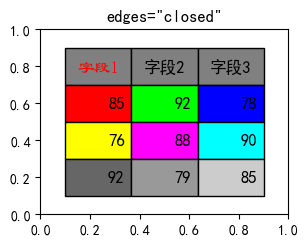

In [116]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
# 示例数据
cellText = [
    [85, 92, 78],
    [76, 88, 90],
    [92, 79, 85]
]
cellColours = [
    [(1, 0, 0), (0, 1, 0), (0, 0, 1)],
    [(1, 1, 0), (1, 0, 1), (0, 1, 1)],
    [(0.4, 0.4, 0.4), (0.6, 0.6, 0.6), (0.8, 0.8, 0.8)]
]
colLabels = [ "字段1", "字段2", "字段3"]
colColours = ["gray", "gray", "gray"]
colLoc = "center"


plt.figure(figsize=(3.2, 2.4))

table = plt.table(
    cellText=cellText,
    cellColours=cellColours,
    cellLoc='right',
    bbox=[0.1, 0.1, 0.8, 0.8],
    colLabels=colLabels,
    colColours=colColours,
    colLoc=colLoc,
    edges= "closed",
    fontsize=12
)

# 通过Table对象，获取单元格对象，最后访问Text对象来设置
print(table.get_celld())  # matplotlib.table.Cell
print(type(table.get_celld()))
cells = table.get_celld()  # 返回的单元格是字典。key是单元格下标格式的坐标，value是Cell对象。
# for loc, cell in cells.items():
#     cell.set_text_props(color="red")  # 设置每个单元格的文本属性。

# 直接设置某个单元格的文本属性
cells[(0, 0)].set_text_props(color="red", family="LiSu", fontsize=36)
    
plt.title('edges="closed"')

plt.show()

- 最后说明，表格默认是绘制在坐标系下面，这种位置安排实际上是允许表格与其他图表一起绘制。

- 代码说明：
    - 表格Table对象中的fontsize属性与Cell对象的set_text_props函数设置的fonsize两个数据都设置的时候，我们通过测试得出结论，最终绘制的时候，取的最小值。
    - 在代码中的Table对象与Cell对象，我们没有进一步说明。

## 3.10. 向量场

- 向量场（Vector fields）是一个将空间中每个点映射到一个向量的函数。简单来说，它是在空间（如二维平面或三维空间）的每个点上都有一个向量与之对应的场。向量场的应用常见的有：
    - 气象学中可视化风速和风向场
    - 电磁学中可视化电场和磁场分布
    - 流体动力学中可视化流速场
    - 计算机图形学中可视化粒子系统
    - 机器人学中可视化运动规划中的势场
    - 地质学中可视化地壳应力场

### (1) 箭头图绘制-quiver/quiverkey函数

- quiver函数负责绘制二维向量场（箭头图），它能够在**指定位置**绘制**带有方向和大小的箭头**，非常适合可视化速度场、力场、梯度等向量数据。

- quiver函数的原型定义与参数说明：

```python
matplotlib.pyplot.quiver(
    *args,  # 使用变长参数，箭头图的核心数据与属性
    data=None,  # 结构化数据，通过字段设置箭头图的核心数据，字段可以在`*args`参数中通过字符串使用。
    **kwargs)  # 使用关键字参数设置的属性，以及设置来自PolyCollection对象的属性
```

函数返回Quiver对象。

- 通过`*args`设置的核心参数，可以使用如下形式表达：`quiver([X, Y], U, V, [C], /, **kwargs)`，注意：通过`*args`形式定义的参数，必须是位置参数，下面描述的都是位置参数：
    - X,Y参数：可选参数，数据格式是1D或者2D数组，参数设置箭头的位置坐标。
    - U,V参数：必须参数，数据格式是1D或者2D数组，参数设置箭头向量在x, y坐标轴的分量。参数的长度与X,Y一样。箭头的实际方向计算 = $arctan(V/U)$，箭头的长度计算=$\sqrt{(U² + V²)}$
    - C参数：可选参数，参数格式是1D或者2D的数组，用来通过cmap映射为颜色。

- X,Y,U,V,C参数的使用例子

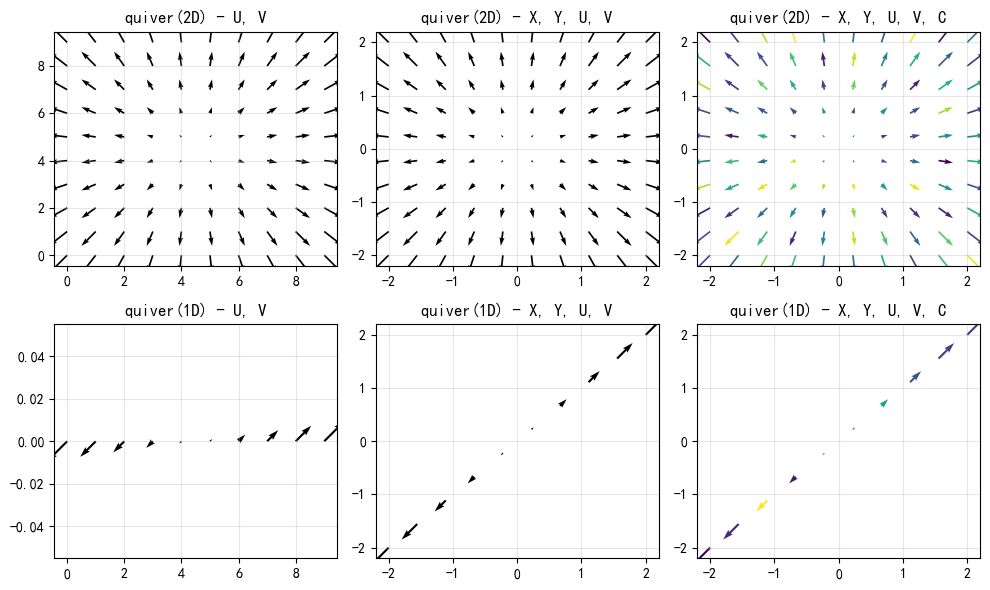

In [143]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

rng = np.random.default_rng(12345)

# 创建网格
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)

C = rng.random(X.shape)
c = rng.random(x.shape)
# 定义向量场
u = x
v = y
U = X  # x分量
V = Y  # y分量


plt.figure(figsize=(10, 6))

# --------------- 使用2D数组----------------------------
# - 当没有X，Y的时候，使用数组的下标作为X，Y
plt.subplot(231)
plt.quiver(U, V)
plt.title('quiver(2D) - U, V')
plt.grid(True, alpha=0.3)

# - X,Y,U,V
plt.subplot(232)
plt.quiver(X, Y, U, V)
plt.title('quiver(2D) - X, Y, U, V')
plt.grid(True, alpha=0.3)

# - X,Y,U,V,C
plt.subplot(233)
plt.quiver(X, Y, U, V, C)
plt.title('quiver(2D) - X, Y, U, V, C')
plt.grid(True, alpha=0.3)

# --------------- 使用1D数组----------------------------
plt.subplot(234)
plt.quiver(u, v)
plt.title('quiver(1D) - U, V')
plt.grid(True, alpha=0.3)

# - X,Y,U,V
plt.subplot(235)
plt.quiver(x, y, u, v)
plt.title('quiver(1D) - X, Y, U, V')
plt.grid(True, alpha=0.3)

# - X,Y,U,V,C
plt.subplot(236)
plt.quiver(x, y, u, v, c)
plt.title('quiver(1D) - X, Y, U, V, C')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- 代码说明：
    - U,V是必须的，如果只有两个参数，则作为U，V使用，X，Y使用U,V的下标。
    - 如果使用1D数组，没有X，Y参数，则向量绘制的坐标的y分量都是0。

- 使用angles参数设置箭头的角度计算魔术
    - quiver函数的X，Y，U，V，C等以外的其他参数设置，必须是关键字参数，在原型定义中都是通过`**kwargs`参数设置。
    - angles：设置箭头的角度。取值{'uv', 'xy'}，默认是'uv'（就是计算角度的公式：$arctan(V/U)$），取值'xy'，则角度计算公式：$arctan(Y/X)$

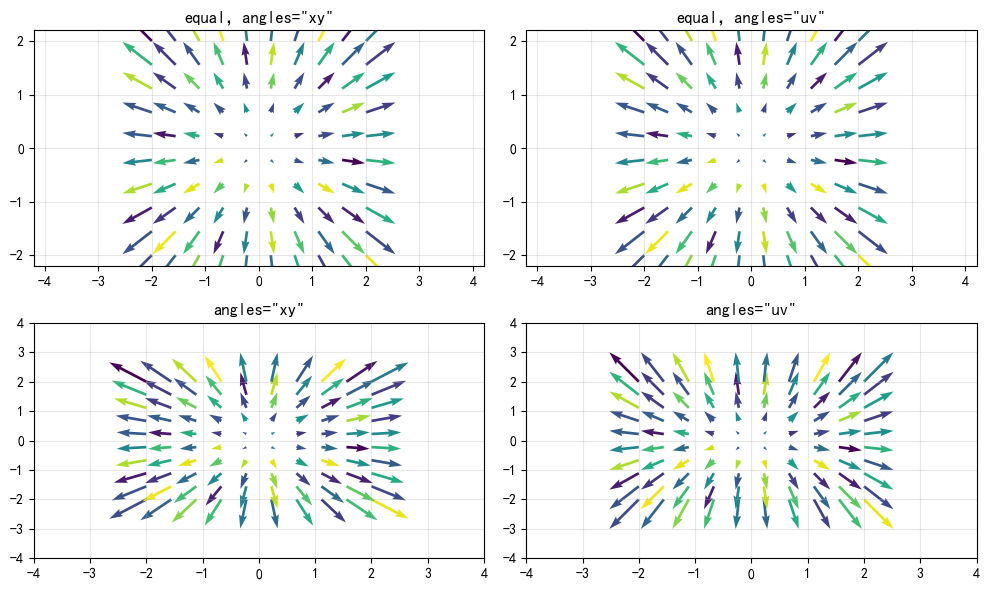

In [162]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

rng = np.random.default_rng(12345)

# 创建网格
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)
C = rng.random(X.shape)
# 定义向量场
U = X  # x分量
V = Y  # y分量


plt.figure(figsize=(10, 6))

# --------------- 使用X,Y轴等长----------------------------
plt.subplot(221)
plt.quiver(X, Y, U, V, C, angles="xy")
plt.title('equal，angles="xy"')
plt.grid(True, alpha=0.3)
plt.axis("equal")


# - X,Y,U,V
plt.subplot(222)
plt.quiver(X, Y, U, V, C, angles="uv")
plt.title('equal，angles="uv"')
plt.grid(True, alpha=0.3)
plt.axis("equal")


# --------------- 使用X,Y轴不等长----------------------------

plt.subplot(223)
plt.quiver(X, Y, U, V, C, angles="xy")
plt.title('angles="xy"')
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)
plt.ylim(-4, 4)

# - X,Y,U,V
plt.subplot(224)
plt.quiver(X, Y, U, V, C, angles="uv")
plt.title('angles="uv"')
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)
plt.ylim(-4, 4)

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们在上面两个图表中使用了`plt.axis("equal")`,是的x,y轴单位相等，angles参数使用xy与uv的结果一样。
    - 我们在下面两个图表中没有使用`plt.axis("equal")`,ngles参数使用xy与uv的结果明显不同，uv绘制的是实际的角度（比如45°，显示出来就是物理上的45°）。xy绘制的是经过坐标系处理的角度（比如45°，因为x，y轴单位不同，45°依然是对角线，但是物理上显示的实际不是45°）
    - xy与uv两种模式的角度计算公式相同，但渲染时的参考坐标系系和长度计算不同，导致在非等距坐标系中视觉效果有差异。
    - 上面图表重点观察x=y的点的位置的角度来比较区别差异。

- 使用pivot参数控制箭头的旋转支点（旋转角度按照angles指定的计算方式计算）
    - 参数取值{'tail', 'mid', 'middle', 'tip'},其中mid与middle是一样的，mid是middle的别称。
    - tail：箭头围绕尾部（起点）旋转（从上面效果看，这是默认值）
    - mid：箭头围绕中心点旋转
    - tip：箭头围绕头部（终点）旋转

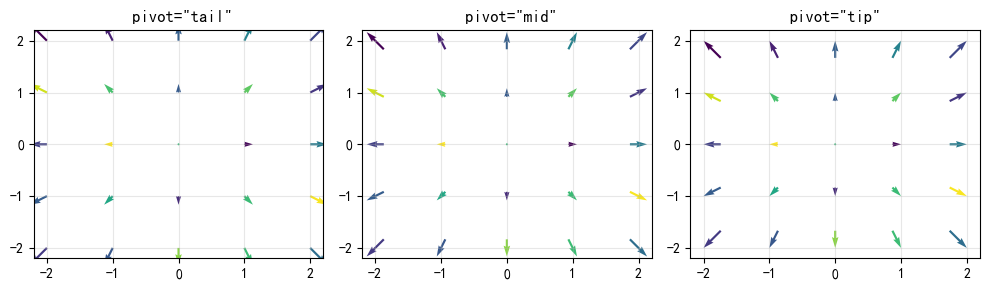

In [164]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

rng = np.random.default_rng(12345)

# 创建网格
x = np.linspace(-2, 2, 5)
y = np.linspace(-2, 2, 5)
X, Y = np.meshgrid(x, y)
C = rng.random(X.shape)
# 定义向量场
U = X  # x分量
V = Y  # y分量


plt.figure(figsize=(10, 3))

# --------------- tail----------------------------
plt.subplot(131)
plt.quiver(X, Y, U, V, C, pivot="tail")
plt.title(' pivot="tail"')
plt.grid(True, alpha=0.3)
# --------------- mid----------------------------
plt.subplot(132)
plt.quiver(X, Y, U, V, C, pivot="mid")
plt.title(' pivot="mid"')
plt.grid(True, alpha=0.3)

# --------------- tip----------------------------
plt.subplot(133)
plt.quiver(X, Y, U, V, C, pivot="tip")
plt.title('pivot="tip"')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

- 代码说明：
    - 为了便于观察，我们取x，y在`-2, -1, 0, 1, 2`整数处。
    - 注意比较三个图表的箭头开始，中间与结束位置。
    - 结论：pivot参数可以微调箭头的开始坐标与结束坐标，但是方向不会改变（由U,V决定）

- 控制箭头大小、外观相关的参数：
    - scale，scale_units参数控制箭头的整体缩放（尤其是箭头的整体长度）：
        - scale：控制箭头的反向缩放，值越大，箭头越短；值越小，箭头越长。参数类型是float。默认情况下自动计算缩放量，默认值取决于平均矢量长度和矢量数量。
        - scale_units：指定缩放值的单位，取值{'width', 'height', 'dots', 'inches', 'x', 'y', 'xy'}，默认值是'width'
            - 'width', 'height'：相对于Figure的宽度/高度
            - 'dots', 'inches'：点与英寸。
            - 'x', 'y'：数据坐标系单位。
            - 'xy'：$\sqrt{X^2 + Y^2}$
    - units，width参数控制箭头的大小：
        - units：设置箭头柄的宽度的单位。取值{'width', 'height', 'dots', 'inches', 'x', 'y', 'xy'},默认值 'width'。这些取值的含义与scale_units一样。
        - width；设置箭头柄的宽度。
    - headwidth，headlength，headaxislength，minshaft，minlength控制箭头形状：
        - headwidth：箭头宽度（以箭柄宽度的倍数表示）
        - headlength：箭头长度（以箭柄宽度的倍数表示）
        - headaxislength：
        - minshaft：最小柄长度
        - minlength：最小总长度
    - color参数控制箭头颜色：
        - 这个参数以C值都控制箭头颜色。color在C值存在的情况下无效。参数类型是颜色或者颜色数组。

- scale，scale_units参数的使用例子：

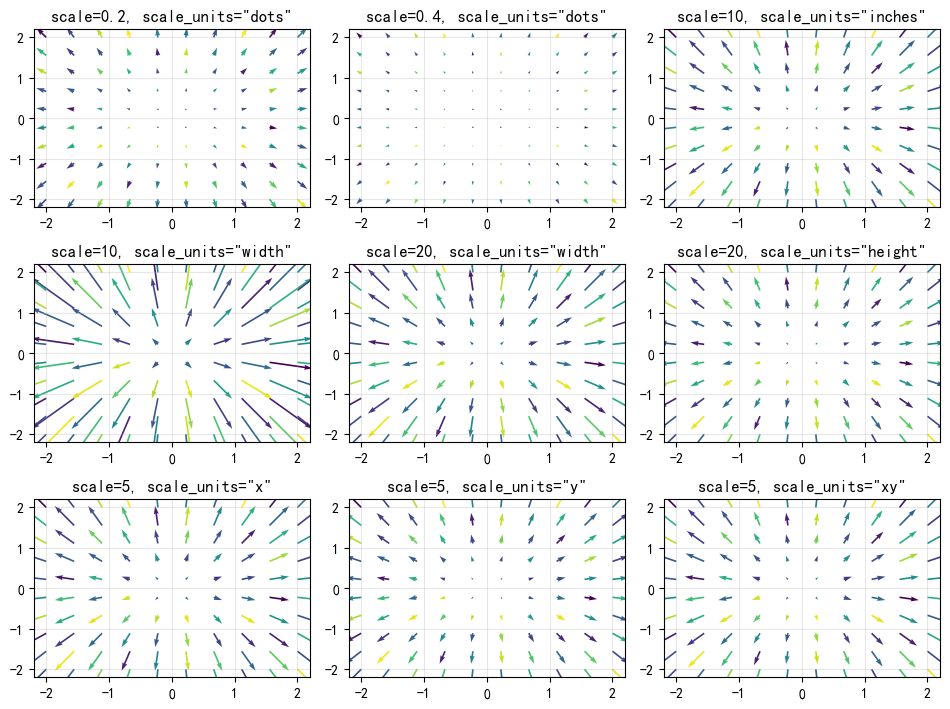

In [189]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

rng = np.random.default_rng(12345)

# 创建网格
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)
C = rng.random(X.shape)
# 定义向量场
U = X  # x分量
V = Y  # y分量


plt.figure(figsize=(9.6, 7.2))

# --------------- scale，scale_units----------------------------
# **********dots单位
plt.subplot(331)
plt.quiver(X, Y, U, V, C, scale=0.2, scale_units="dots")
plt.title('scale=0.2, scale_units="dots"')
plt.grid(True, alpha=0.3)

plt.subplot(332)
plt.quiver(X, Y, U, V, C, scale=0.4, scale_units="dots")
plt.title('scale=0.4, scale_units="dots"')
plt.grid(True, alpha=0.3)

plt.subplot(333)
plt.quiver(X, Y, U, V, C, scale=10, scale_units="inches")
plt.title('scale=10, scale_units="inches"')
plt.grid(True, alpha=0.3)

# **********width，height单位
plt.subplot(334)
plt.quiver(X, Y, U, V, C, scale=10, scale_units="width")
plt.title('scale=10, scale_units="width"')
plt.grid(True, alpha=0.3)


plt.subplot(335)
plt.quiver(X, Y, U, V, C, scale=20, scale_units="width")
plt.title('scale=20, scale_units="width"')
plt.grid(True, alpha=0.3)

plt.subplot(336)
plt.quiver(X, Y, U, V, C, scale=20, scale_units="height")
plt.title('scale=20, scale_units="height"')
plt.grid(True, alpha=0.3)

# **********x，y，xy单位
plt.subplot(337)
plt.quiver(X, Y, U, V, C, scale=5, scale_units="x")   # data坐标系是标准坐标系
plt.title('scale=5, scale_units="x"')
plt.grid(True, alpha=0.3)

plt.subplot(338)
plt.quiver(X, Y, U, V, C, scale=5, scale_units="y")
plt.title('scale=5, scale_units="y"')
plt.grid(True, alpha=0.3)

plt.subplot(339)
plt.quiver(X, Y, U, V, C, scale=5, scale_units="xy")
plt.title('scale=5, scale_units="xy"')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

- 代码说明：
    - 箭头的长度的计算公式如下；`scale越大箭头越小。`
        - x方向长度 = $\dfrac{u}{\mathrm{scale}} \mathrm{scale\_unit}$
        - y方向长度 = $\dfrac{v}{\mathrm{scale}} \mathrm{scale\_unit}$
    - dots与inches单位比较容易理解，如果能理解，则width与height也能理解（是figsize与dpi决定的Figure大小），根据上面箭头大小的计算公式，这4个单位都是绝对值。
    - x,y理解难点，因为其与坐标系有关，比如data坐标系，这个时候x，y其实就是1。如果是其他坐标系，或者通过xlim,ylim修改后，就是x，y的坐标轴长度，xy就是坐标轴的对角线长度。
    - 这几个代码我们用对比的方式，体验不同单位的影响，以及scale的取值经验。根据不同单位取合适的值，产生合适的箭头大小。
    - 这里箭头大小包含箭柄长度。

- units，width参数的使用例子：
    - 这2个参数控制箭头的宽度。width参数与scale参数的作用一样，与units一起控制箭头宽度的核心数据。但是width是绝对值，scale是缩放值。
        - width越大，箭头越大。
        - scale越大，箭头长度越小。
    - units的度量方式与scale_units一样。

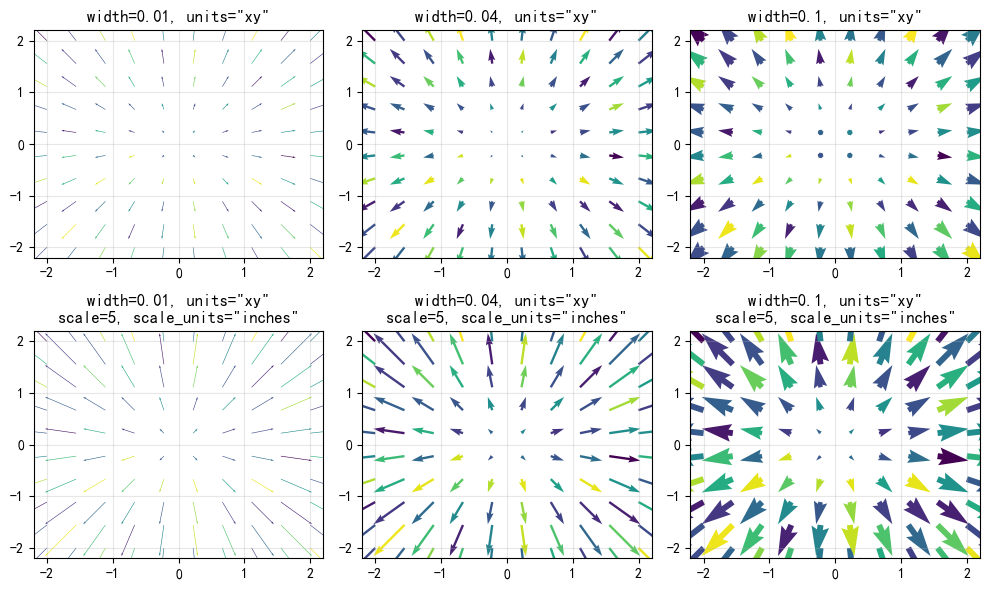

In [201]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

rng = np.random.default_rng(12345)

# 创建网格
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)
C = rng.random(X.shape)
# 定义向量场
U = X  # x分量
V = Y  # y分量


plt.figure(figsize=(10, 6))

# --------------- units，width----------------------------
plt.subplot(231)
plt.quiver(X, Y, U, V, C, width=0.01, units="xy")
plt.title('width=0.01, units="xy"')
plt.grid(True, alpha=0.3)

plt.subplot(232)
plt.quiver(X, Y, U, V, C, width=0.04, units="xy")
plt.title('width=0.04, units="xy"')
plt.grid(True, alpha=0.3)

plt.subplot(233)
plt.quiver(X, Y, U, V, C, width=0.1, units="xy")
plt.title('width=0.1, units="xy"')
plt.grid(True, alpha=0.3)
# ************配合scale与scale_units使用

plt.subplot(234)
plt.quiver(X, Y, U, V, C, width=0.01, units="xy", scale=5, scale_units="inches")
plt.title('width=0.01, units="xy"\nscale=5, scale_units="inches"')
plt.grid(True, alpha=0.3)

plt.subplot(235)
plt.quiver(X, Y, U, V, C, width=0.04, units="xy", scale=5, scale_units="inches")
plt.title('width=0.04, units="xy"\nscale=5, scale_units="inches"')
plt.grid(True, alpha=0.3)

plt.subplot(236)
plt.quiver(X, Y, U, V, C, width=0.1, units="xy", scale=5, scale_units="inches")
plt.title('width=0.1, units="xy"\nscale=5, scale_units="inches"')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- 代码说明：
    - width与units参数控制箭头与箭柄的宽度。我们只使用了xy，而且与scale配合使用体验。
    - 注意width越大，箭头越宽。

- headwidth，headlength，headaxislength，minshaft，minlength参数的使用例子：
    - 这几个参数是在箭头整体长度与宽度基础上，微调箭头的头的宽度与长度。
    - headwidth是箭柄宽度的倍数来度量。
    - headlength也是箭柄宽度的倍数来度量（不是箭杆的长度）。

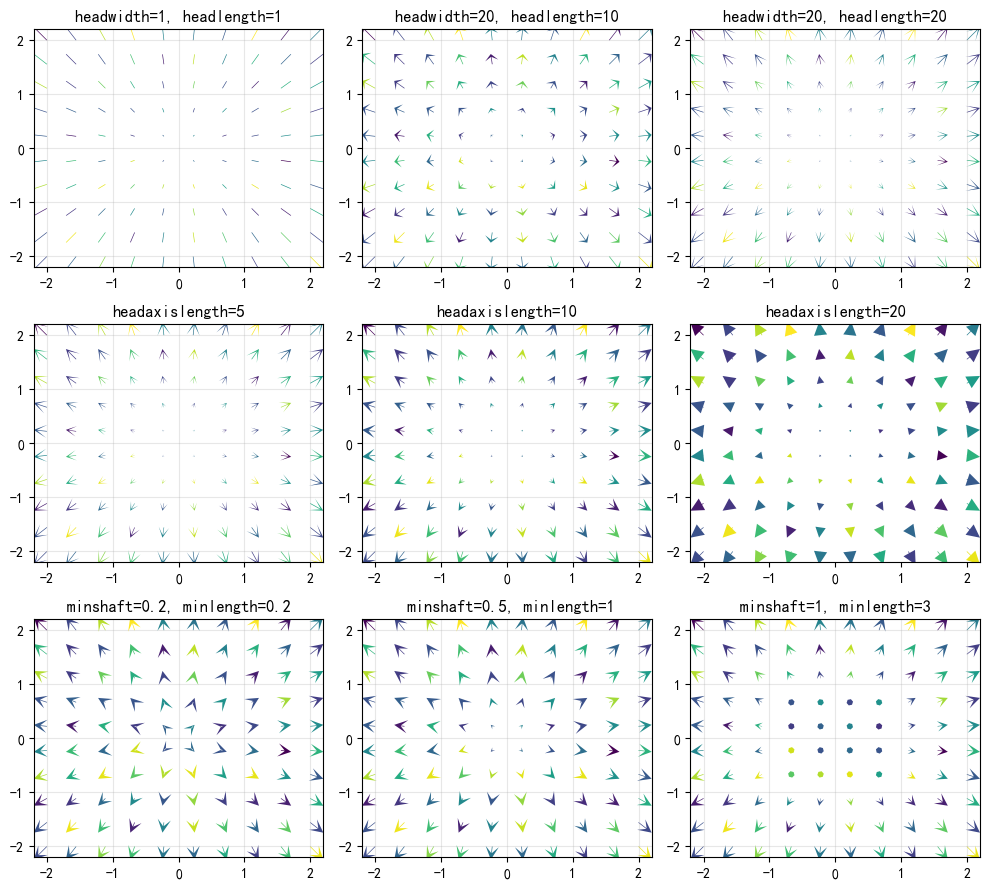

In [263]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

rng = np.random.default_rng(12345)

# 创建网格
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)
C = rng.random(X.shape)
# 定义向量场
U = X  # x分量
V = Y  # y分量


plt.figure(figsize=(10, 9))

# --------------- headwidth，headlength，headaxislength，minshaft，minlength----------------------------
# **********箭头宽与长**********
plt.subplot(331)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=1, headlength=1
)
plt.title('headwidth=1, headlength=1')
plt.grid(True, alpha=0.3)

plt.subplot(332)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=20, headlength=10
)
plt.title('headwidth=20, headlength=10')
plt.grid(True, alpha=0.3)

plt.subplot(333)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=20, headlength=20
)
plt.title('headwidth=20, headlength=20')
plt.grid(True, alpha=0.3)
# **********箭头的翼展**********
plt.subplot(334)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=20, headlength=20,
           headaxislength=5,
)
plt.title('headaxislength=5')
plt.grid(True, alpha=0.3)

plt.subplot(335)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=20, headlength=20,
           headaxislength=10,
)
plt.title('headaxislength=10')
plt.grid(True, alpha=0.3)

plt.subplot(336)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=20, headlength=20,
           headaxislength=20,
)
plt.title('headaxislength=20')

# **********箭头的最小箭柄宽度与箭头总长度**********
plt.subplot(337)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=20, headlength=20,
           headaxislength=10,
           minshaft=0.2, minlength=0.2
)
plt.title('minshaft=0.2, minlength=0.2')
plt.grid(True, alpha=0.3)

plt.subplot(338)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=20, headlength=20,
           headaxislength=10,
           minshaft=0.5, minlength=1
)
plt.title(' minshaft=0.5, minlength=1')
plt.grid(True, alpha=0.3)

plt.subplot(339)
plt.quiver(X, Y, U, V, C, 
           scale=10, scale_units="x",
           width=0.01, units="x",
           headwidth=20, headlength=20,
           headaxislength=10,
           minshaft=1, minlength=10
)
plt.title('minshaft=1, minlength=10')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- 代码说明：
    - 图表的第一行，说明headwidth，headlength参数,控制箭头头部长宽。
    - 图表的第二行，说明headaxislength参数，控制箭头翼展（及时箭头两边的刺）
    - 图表的第三行，说明minshaft，minlength参数，控制箭柄的最小长度，与箭头最小总长度。注意参考度量：
        - minshaft以头部长度为单位
        - minlength以箭杆宽度的倍数表示
    - 我们实际运行效果，上面的很多参数的参照值都是随着U，V变化的。箭头的长宽随着U,V而不同，所以上面参数也是变化的，不是虽有箭头的最终的值都一样。

- 下面我们使用比较规范的数据来对比显示这些箭头的参数的效果。(不受坐标系影响)

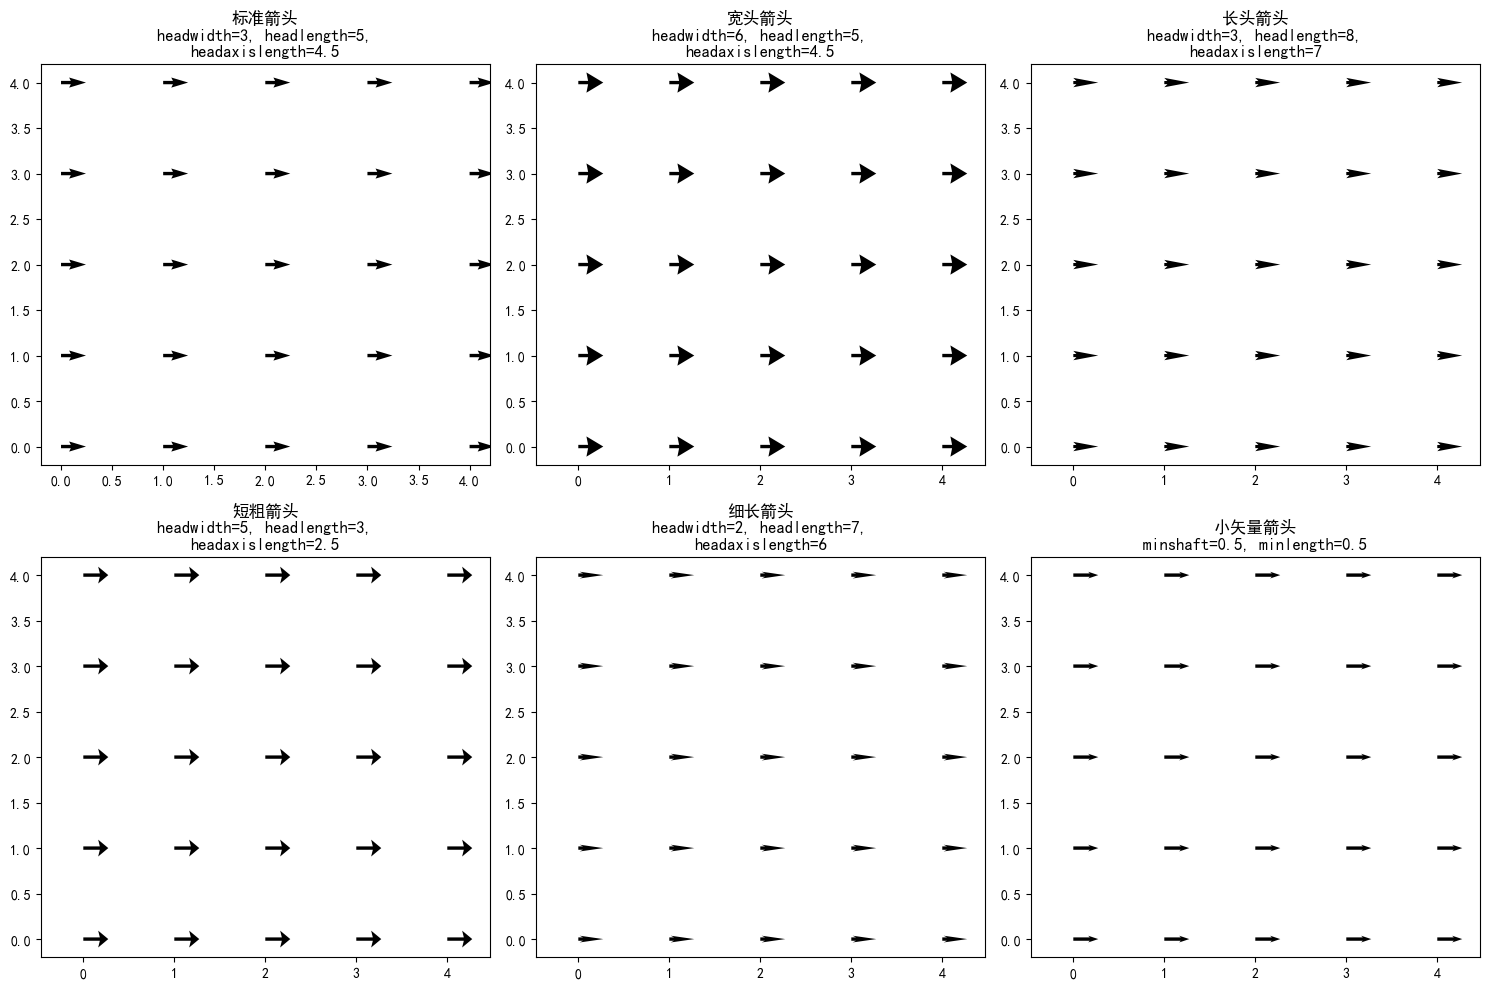

In [267]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建网格数据
x = np.linspace(0, 4, 5)
y = np.linspace(0, 4, 5)
X, Y = np.meshgrid(x, y)
U = np.ones_like(X)
V = np.zeros_like(Y)

plt.figure(figsize=(15, 10))

# 标准箭头
plt.subplot(231)
plt.quiver(X, Y, U, V, headwidth=3, headlength=5, headaxislength=4.5)
plt.title('标准箭头\nheadwidth=3, headlength=5,\nheadaxislength=4.5')

# 宽头箭头
plt.subplot(232)
plt.xlim(-0.5, 4.5)
plt.ylim(-0.5, 4.5)
plt.axis('equal')
plt.quiver(X, Y, U, V, headwidth=6, headlength=5, headaxislength=4.5)
plt.title('宽头箭头\nheadwidth=6, headlength=5,\nheadaxislength=4.5')

# 长头箭头
plt.subplot(233)
plt.xlim(-0.5, 4.5)
plt.ylim(-0.5, 4.5)
plt.axis('equal')
plt.quiver(X, Y, U, V, headwidth=3, headlength=8, headaxislength=7)
plt.title('长头箭头\nheadwidth=3, headlength=8,\nheadaxislength=7')

# 短粗箭头
plt.subplot(234)
plt.xlim(-0.5, 4.5)
plt.ylim(-0.5, 4.5)
plt.axis('equal')
plt.quiver(X, Y, U, V, headwidth=5, headlength=3, headaxislength=2.5)
plt.title('短粗箭头\nheadwidth=5, headlength=3,\nheadaxislength=2.5')

# 细长箭头
plt.subplot(235)
plt.xlim(-0.5, 4.5)
plt.ylim(-0.5, 4.5)
plt.axis('equal')
plt.quiver(X, Y, U, V, headwidth=2, headlength=7, headaxislength=6)
plt.title('细长箭头\nheadwidth=2, headlength=7,\nheadaxislength=6')

# 极小箭头
plt.subplot(236)
plt.xlim(-0.5, 4.5)
plt.ylim(-0.5, 4.5)
plt.axis('equal')
plt.quiver(X, Y, U*0.3, V, headwidth=2, headlength=3, headaxislength=2.5,
                minshaft=0.5, minlength=0.5)
plt.title('小矢量箭头\nminshaft=0.5, minlength=0.5')

plt.tight_layout()
plt.show()

- quiverkey函数的原型定义与参数说明：
    - 为quiver函数绘制的图表添加参考箭头的函数。它可以在图中显示一个带有标度值的参考箭头，帮助读者理解图中箭头的尺度。

```python
matplotlib.pyplot.quiverkey(
    Q,   # 由quiver函数返回的Quiver对象
    X, Y, # 参考箭头的位置
    U,  # 参考箭头代表的数值大小
    label,  # 标签
    **kwargs)  # 其他关键字参数。与来自Quiver对象的属性参数。
```

- 其他关键字参数有：
    - angle：键箭头相对于水平轴的角度（逆时针）
    - coordinates：坐标系类型，取值{'axes', 'figure', 'data', 'inches'}, 默认是'axes'。
    - color：参考箭头的颜色。
    - labelpos：标签位置，取值{'N', 'S', 'E', 'W'}，表示四个东西南北四个方位。
    - labelsep：标签与箭头的间距，默认值0,1，单位是inches。
    - labelcolor：标签颜色，默认值是black，该参数值默认从环境参数`rcParams["text.color"]`获取。
    - fontproperties：字体属性（前面介绍的6大字体属性）
    - zorder：默认值是0.1，表示参考箭头在箭头图上面。

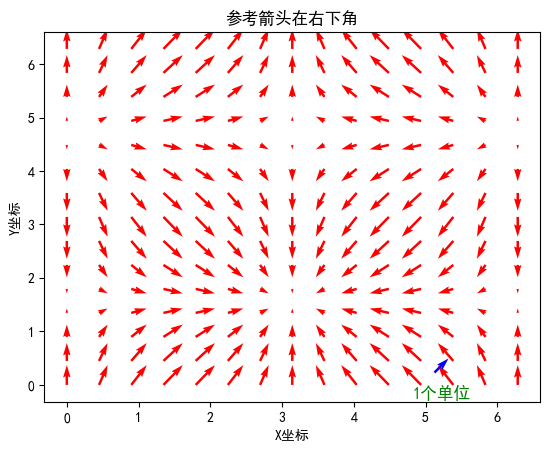

In [278]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建数据
x = np.linspace(0, 2*np.pi, 15)
y = np.linspace(0, 2*np.pi, 15)
X, Y = np.meshgrid(x, y)
U = np.sin(X)  # x方向速度分量
V = np.cos(Y)  # y方向速度分量

# 创建图形

Q = plt.quiver(X, Y, U, V, color='red', scale=25, width=0.005)
plt.quiverkey(
    Q, 
    0.8, 0.1, 
    1, 
    '1个单位', 
    angle=45,   # 参考箭头在45°方向
    coordinates="axes", # 参考箭头的坐标系，建议与Q的坐标系一样。
    labelpos='S',   # 标签在参考箭头的南面。
    labelsep=0.2,  # 标签与箭头之间的距离，单位是英寸
    color='blue', labelcolor='green',  # 箭头与标签的颜色
    fontproperties={'weight': 'bold', 'size': 12})
plt.title('参考箭头在右下角')
plt.xlabel('X坐标')
plt.ylabel('Y坐标')

plt.show()

- 代码说明：
    - quiverkey函数的使用比较简单，说明在代码中使用注释已经解释，就不再赘述。

### (2) 风羽图绘制-barbs函数

- barbs函数负责绘制风羽图（wind barbs）的专业函数，绘制的图表主要用于气象、海洋等领域可视化风向和风速数据等。
    - 风羽图大家在看天气预报的时候，应该经常看见。

- barbs函数的原型定义与参数说明：

```python
matplotlib.pyplot.barbs(
    *args,      # 绘制风羽图的核心参数：坐标X,Y（可选），方向U,V（必须），数值C（可选），这些参数按照函数定义，必须是位置参数。
    data=None,  # 结构化数据，通过data参数，X,Y，U，V，C可以使用data的结构化数据中的字符串字段。
    **kwargs)  # 关键字参数，主要来自PolyCollection对象的属性
```

函数返回Barbs对象（也是PolyCollection类型）

- barbs函数的核心数据参数的使用例子：
    - X,Y设置位置
    - U,V设置方向
    - C设置值（值映射成颜色可视化表示）

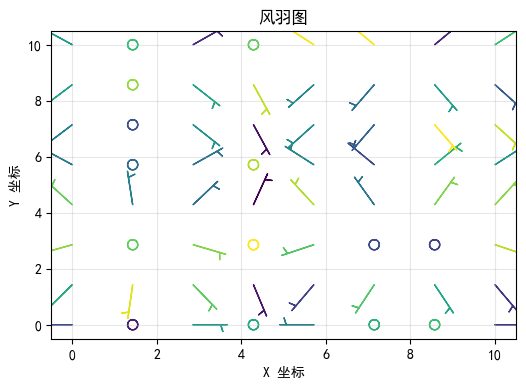

In [284]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建示例数据
x = np.linspace(0, 10, 8)
y = np.linspace(0, 10, 8)
X, Y = np.meshgrid(x, y)

# 分量（U: 东西方向, V: 南北方向）
U = np.cos(X) * 3  # 东西方向
V = np.sin(Y) * 3  # 南北方向

rng = np.random.default_rng()
C = rng.random(X.shape)

# 绘制风羽图
plt.figure(figsize=(6, 4))
plt.barbs(X, Y, U, V, C)
plt.title('风羽图')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.grid(True, alpha=0.3)
plt.show()

- badbs函数的关键字参数：
    - length：风羽的总长度（单位：点），参数类型是float，默认值是7。
    - pivot：风羽的旋转支点，取值{'tip', 'middle'}或者float类型，默认是'tip'。 如果是float，则是风羽的起点从X，Y，参照UV的偏移的偏移的点数。
    - barb_increments：自定义风羽增量单位，参数类型是dict字典类型，字典只支持三个key：
        - 'half': 短线
        - 'full': 长线
        - 'flag': 三角旗
    - color：设置所有风羽元素的颜色
    - barbcolor / flagcolor：分别设置风羽线和三角旗的颜色，参数类型是颜色，或者颜色数组。
    - sizes：控制风羽各部分的缩放比例，参数类型是指定字段的dict字典类型:
        -  'spacing': 风羽间距
        -  'height': 风羽高度
        -  'width': 风羽宽度
        -  'emptybarb': 空风羽比例
    - fill_empty：是否用圆圈标记零风速,参数类型是bool类型，默认值是False。
    - rounding：风速舍入规则（四舍五入），参数bool类型，默认是True。
    - flip_barb：线条和旗帜是否应指向与正常相反的方向。正常的行为是倒钩和线条指向右侧（翻转线条与旗帜），参数类型是bool（全部），或者bool数组（长度UV对应）。
    - 来自PolyCollection 对象的属性参数：
        - linestyle：线条样式
        - linewidth：线条宽度

- length参数的使用例子：

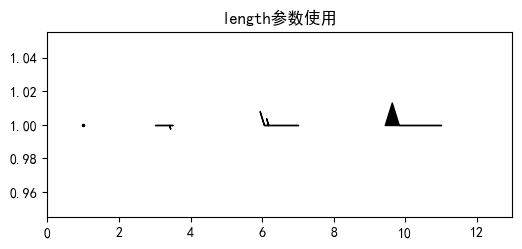

In [308]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
x = [1, 3, 7, 11]
y = [1, 1, 1, 1]
U = [0, 5, 15, 50]
V = [0, 0,  0,  0]
plt.figure(figsize=(6, 2.4))
for i, l in enumerate([3, -5, 7, 9]):
    plt.barbs(x[i], y[i], U[i], V[i], length=l, label=f'length={l}')

plt.xlim(0, 13)
plt.title('length参数使用')
plt.show()

- 代码说明：
    - 我们是逐个绘制每个风羽图形。
    - `for i, l in enumerate([3, -5, 7, 9]):`代码表示我们绘制的风羽长度分别是3, 5, 7, 9。单位是points。 使用负数可以改变方向。-5表示向西。9表示向东。
    - 注意：`U = [0, 15, 50]`控制风羽向量的东西方向。正数是东面，负数是西面。`V = [0, 0, 0]`控制风羽的南北面，北面是正。
    - 风羽的形状：0表示圆圈，5表示短线，10表示长线，50表示三角旗。

- 使用barb_increments参数改变风羽的形状的例子：
    - 默认是风羽是5（短线）,10（长线）,50（三角旗）三个阈值。这个可以使用barb_increments参数改变，该参数使用三个key来控制三个阈值：
        - 'half' - 半风羽(默认是5)
        - 'full' - 全风羽(默认是10)
        - 'flag' - 旗子(默认是50)

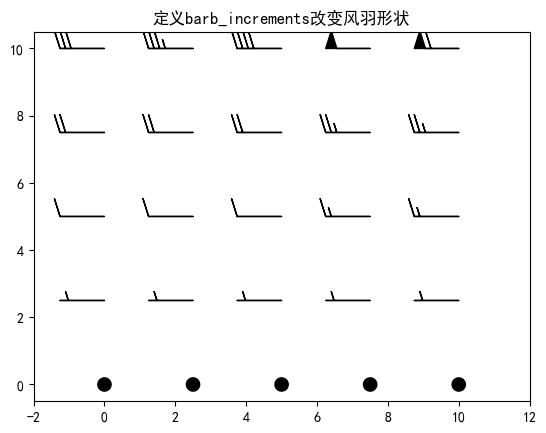

In [317]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
# 自定义增量单位
increments = {
    'half': 2.5,    # 短线
    'full': 5.0,    # 长线  
    'flag': 25.0    # 三角旗
}
x = np.linspace(0, 10, 5)
y = np.linspace(0, 10, 5)
X, Y = np.meshgrid(x, y)

U = np.array([[0, 0.5, 1, 1.5, 2],
              [2.5, 3, 3.5, 4.0, 4.5],
              [5, 6, 7, 8, 9],
              [10, 11, 12, 13, 14],
              [15, 18, 20, 25, 30]])
V = np.zeros_like(U)


plt.barbs(X, Y, U, V,
          barb_increments=increments,
          length=8,
          fill_empty=True,
          rounding=True
         )
plt.title('定义barb_increments改变风羽形状')
plt.xlim(-2, 12)
plt.show()

- 代码说明：
    - 代码中我们设置了2.5, 5, 30的阈值，并显示不同向量长度下的风羽绘制效果。
    - 其中在介于两个阈值之间的值绘制什么样的风羽图，由rounding参数指定采用四舍五入还是直接截断来判断。
    - fill_empty参数对0值是否对0值的圆圈进行填充。默认是空心。
    - 代码中我们没有对rounding与fill_empty采用对比的方式，使用者可以修改这两个参数，并运行体验变化。

- 使用sizes来微调风羽的绘制例子：
    - sizes参数类型是dict字典类型，字典的关键字对应需要调整的绘制参数：
        - 'spacing' -同一杆上相邻风羽之间的间距
        - 'height' - 风羽的高度
        - 'width' - 风羽的宽度
        - 'emptybarb' - 当向量为0或很小时显示的短线长度

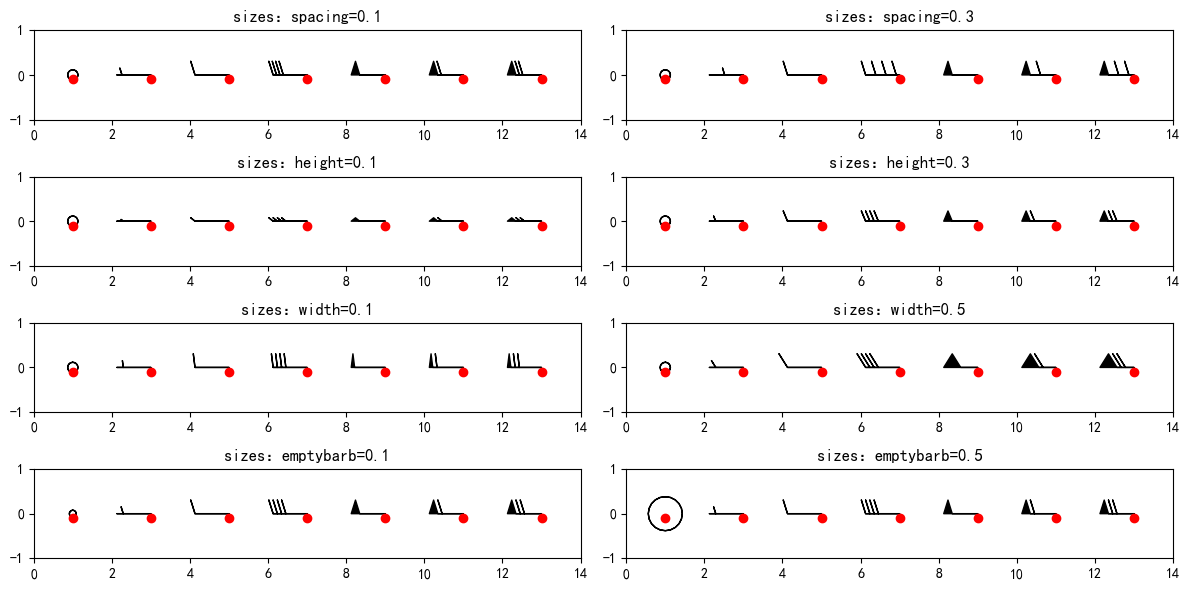

In [348]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

X = [1, 3, 5, 7, 9, 11, 13]
Y = [0, 0, 0, 0, 0,  0,  0]
Y1 = [y-0.1 for y in Y]

U = [0, 5, 10,  40, 50, 60, 70]
V = [0, 0,  0,   0,  0,  0,  0]  

plt.figure(figsize=(12, 6))
# --------------spacing -------------
plt.subplot(421)
plt.xlim(0, 14)
plt.ylim(-1, 1)
plt.plot(X, Y1, "ro")
sizes = {
    'spacing': 0.1,    # 减小间距
}
plt.barbs(X, Y, U, V, sizes=sizes)
plt.title('sizes：spacing=0.1')

plt.subplot(422)
plt.xlim(0, 14)
plt.ylim(-1, 1)
plt.plot(X, Y1, "ro")
sizes = {
    'spacing': 0.3,    # 减小间距
}
plt.barbs(X, Y, U, V, sizes=sizes)
plt.title('sizes：spacing=0.3')
# --------------height -------------
plt.subplot(423)
plt.xlim(0, 14)
plt.ylim(-1, 1)
plt.plot(X, Y1, "ro")
sizes = {
    'height': 0.1,    # 减小间距
}
plt.barbs(X, Y, U, V, sizes=sizes)
plt.title('sizes：height=0.1')

plt.subplot(424)
plt.xlim(0, 14)
plt.ylim(-1, 1)
plt.plot(X, Y1, "ro")
sizes = {
    'height': 0.3,    # 减小间距
}
plt.barbs(X, Y, U, V, sizes=sizes)
plt.title('sizes：height=0.3')
# --------------width -------------
plt.subplot(425)
plt.xlim(0, 14)
plt.ylim(-1, 1)
plt.plot(X, Y1, "ro")
sizes = {
    'width': 0.1,    # 减小间距
}
plt.barbs(X, Y, U, V, sizes=sizes)
plt.title('sizes：width=0.1')

plt.subplot(426)
plt.xlim(0, 14)
plt.ylim(-1, 1)
plt.plot(X, Y1, "ro")
sizes = {
    'width': 0.5,    # 减小间距
}
plt.barbs(X, Y, U, V, sizes=sizes)
plt.title('sizes：width=0.5')
# --------------emptybarb -------------
plt.subplot(427)
plt.xlim(0, 14)
plt.ylim(-1, 1)
plt.plot(X, Y1, "ro")
sizes = {
    'emptybarb': 0.1,    # 减小间距
}
plt.barbs(X, Y, U, V, sizes=sizes)
plt.title('sizes：emptybarb=0.1')

plt.subplot(428)
plt.xlim(0, 14)
plt.ylim(-1, 1)
plt.plot(X, Y1, "ro")
sizes = {
    'emptybarb': 0.5,    # 减小间距
}
plt.barbs(X, Y, U, V, sizes=sizes)
plt.title('sizes：emptybarb=0.5')
plt.tight_layout()
plt.show()

- 代码说明：
    - 代码中，我们对每个sizes的字典关键字都采用对比的方式体验，每个关键字控制的风羽的部位都非常直观。选择合适的值，需要反复调试后获得。

- 与颜色相关的参数我们不再使用例子说明，其作用也是比较易见的。
    - barbcolor：除旗子以外的颜色
    - flagcolor：旗子的颜色。

### (3) 流线图绘制-streamplot函数

- streamplot负责绘制矢量场流线图的函数，它能够可视化地展示二维矢量场的流动模式和方向。

- streamplot函数的原型定义与参数说明

```python
matplotlib.pyplot.streamplot(
    x, y,   # 定义矢量场坐标的网格点
    u, v,   # 矢量场的x分量和y分量, 与x, y形状保持一致
    density=1,  # 控制流线密度
    linewidth=None, # 流线的宽度
    color=None,  # 流线的颜色
    cmap=None,   # 颜色映射
    norm=None,   # 颜色映射的标准化处理参数
    arrowsize=1,   # 箭头大小的缩放因子
    arrowstyle='-|>',   # 箭头的样式
    minlength=0.1,     # 流线的最小长度
    transform=None,  # 指定坐标系统的变换，它控制如何将数据坐标转换为显示坐标（这是matplotlib中的基本参数）
    zorder=None,   # 流线与箭头的z方向的顺序
    start_points=None,   # 路线起点的坐标
    maxlength=4.0,   # 流线的最大长度
    integration_direction='both', # 积分方向
    broken_streamlines=True,   # 是否允许流线在遇到奇点时断开
    *, 
    data=None)   # x, y, u, v的结构化数据
```

函数返回StreamplotSet对象。该对象有两个属性用来返回流线(lines属性：LineCollection对象)与箭头（arrows属性：包含FancyArrowPatch对象的PatchCollection对象 ）

- streamplot函数数据核心参数使用例子
    - x，y两个参数构成流线的绘制位置，x，y都是1D或者2D数组。形状必须一样，如果是2D数组，则每行的必须一样长。如果是1D数组，自动生成网格。
        - 如果是1D数组，则会自动使用`np.meshgrid(x_1d, y_1d)`创建网格。
    - u，v两个参数构成流线的绘制方向与长度。u，v是2D数组，行列必须与x，y的长度保持一致，或者与x，y保持同型。

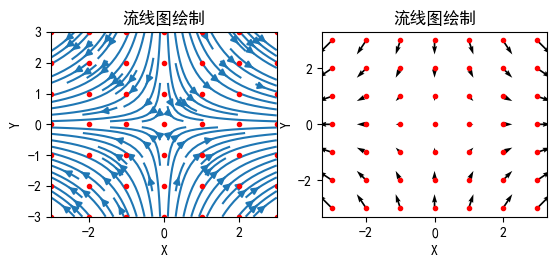

In [371]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建网格
x = np.linspace(-3, 3, 7)
y = np.linspace(-3, 3, 7)
X, Y = np.meshgrid(x, y)

# 创建矢量场 (示例：圆形矢量场)
U = X  # x方向分量
V = -Y   # y方向分量

# 绘制流线图
plt.figure(figsize=(6.4, 2.4))
plt.subplot(121)
plt.streamplot(x, y, U, V, cmap="cool")
plt.plot(U, V, "r.")
# plt.streamplot(X, Y, U, V, cmap="cool")
plt.title('流线图绘制')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(122)
plt.quiver(x, y, U, V, cmap="cool")
plt.plot(U, V, "r.")
# plt.streamplot(X, Y, U, V, cmap="cool")
plt.title('箭头图')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

- 代码说明：
    - 我们使用plot绘制了流线的开始点。
    - 流线的绘制原理：
        - **定义种子**：首先，需要确定从哪些位置开始绘制流线。这些起始位置被称为“种子点”。如果你只提供了网格数据（X, Y, U, V）而没有指定 start_points，streamplot 会使用一个算法自动生成一组种子点。这个算法通常会尝试让流线均匀地分布在图上，避免过度拥挤或稀疏。你也可以通过 start_points 参数精确控制每条流线的起始位置。这在需要突出特定区域流动特性时非常有用。
        - **数值积分（追踪粒子轨迹）**：对于每一个种子点，算法会模拟一个粒子在矢量场中的运动。streamplot通常采用一种叫做 Runge-Kutta方法（特别是二阶的，也称为中点法） 的算法。
        - **流线终止**：追踪不会无限进行下去，当满足以下任一条件时，对该粒子的追踪就会停止
            - 飞出域外：粒子离开了你提供的网格数据范围 (X, Y)
            - 进入奇点：粒子进入了一个速度非常小（接近零）的区域（例如源、汇的中心）。这通过 minlength 和速度模长的阈值来控制。
            - 流线过长：流线长度超过了预设的最大值（由 maxlength 参数控制），防止流线无限缠绕。
            - 形成闭环：如果流线接近一个封闭的环，算法会识别并停止追踪，以避免无限循环。
        - **流线“智能化”与间距控制**：为了让图像清晰美观，streamplot 不是简单地把所有种子点产生的轨迹都画出来。它有一个关键的“智能化”步骤：
            - 流线间距：通过 density 参数可以控制流线的疏密。在内部，算法会维护一个“已经被占据”的空间地图。
            - 碰撞检测：当追踪一条新的流线时，算法会检查它是否与已经画好的流线靠得太近。如果太近，这条新的流线就会被舍弃。这样可以避免流线堆积在一起，形成难看的“毛团”，从而保证流线之间保持一个视觉上舒适的间距。
        - **绘制与样式化**

- 使用start_points参数设置流线图的起点
    - 参数类型：(N, 2)数组，一行两列，代表一个点的坐标。

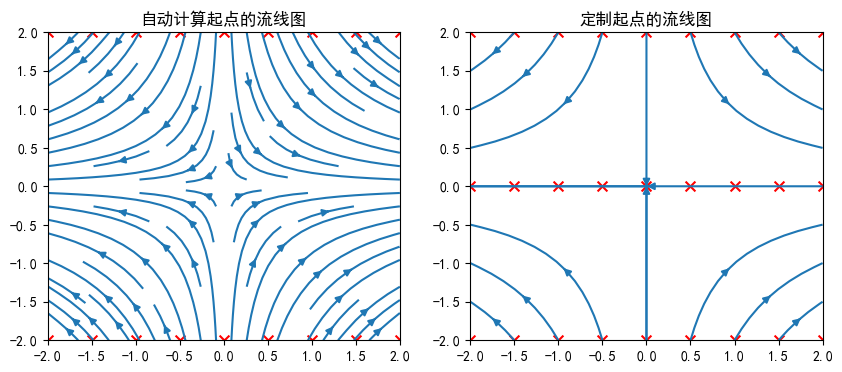

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建更复杂的流场
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
U = X  # x方向分量
V = -Y   # y方向分量

plt.figure(figsize=(10, 4))
plt.subplot(121)
strm = plt.streamplot(X, Y, U, V, 
                     # start_points=start_points,
                     density=0.8)
plt.scatter(start_points[:, 0], start_points[:, 1], c='red', s=50, marker='x')
plt.title('自动计算起点的流线图')

plt.subplot(122)
# 精心选择起始点
# start_points = np.array([
#     [-1.5, 0], [1.5, 0], [0, -1.5], [0, 1.5],
#     [-1, -1], [-1, 1], [1, -1], [1, 1]
# ])
start_points = np.array([
    [-2, 2], [-1.5, 2], [-1, 2], [-0.5, 2], [0, 2], [0.5, 2], [1.0, 2], [1.5, 2], [2, 2],
    [-2, -2], [-1.5, -2], [-1, -2], [-0.5, -2], [0, -2], [0.5, -2], [1.0, -2], [1.5, -2], [2, -2],
    [-2, 0], [-1.5, 0], [-1, 0], [-0.5, 0], [0, 0], [0.5, 0], [1.0, 0], [1.5, 0], [2, 0],
])

strm = plt.streamplot(X, Y, U, V, 
                     start_points=start_points,
                     density=0.8)
plt.scatter(start_points[:, 0], start_points[:, 1], c='red', s=50, marker='x')
plt.title('定制起点的流线图')
plt.show()

- 代码说明：
    - 大家可以想象流线图就是风力图，表示风吹的方向，每个起点是放一个蒲公英，也是蒲公英开始漂流的起点，离线图是就是蒲公英漂流的轨迹。

- 控制流线与箭头的样式，
    - 流线样式是用过线段的相关参数来设置：
        - linewidth：线宽，参数类型float
        - minlength：控制流线最小长度
        - maxlength：控制流线最大长度
    - 箭头样式有两个参数：
        - arrowsize：箭头尺寸，参数类型float。
        - arrowstyle：箭头样式，样式是箭头图中介绍过的花式箭头样式，在FancyArrowPatch类中一样的arrowstyle，箭头样式由ArrowStyle类封装。参数类型是str。
    - 流线的其他样式设置：
        - color：设置流线的颜色。参数类型是颜色（采用统一颜色），或者2D数组，2D数组与U,V长度对应，2D数组的值使用cmap映射到颜色。
        - cmap，norm：当color是2D数组的时候设置映射颜色与归一化处理方式。
    - 流线的密度：
        - density：设置流线的密度，参数类型是float或者(float, float)。
            - float表示流线的整体密度
            - (float, float)表示x，y方向的流线密度
            - 当取值1，表示图表分成`30*30`网格，每个网格最多一条横向流线。 

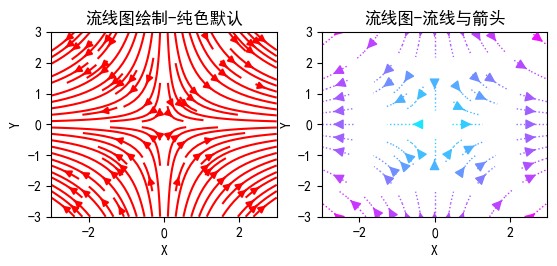

In [35]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建网格
x = np.linspace(-3, 3, 7)
y = np.linspace(-3, 3, 7)
X, Y = np.meshgrid(x, y)

# 创建矢量场 (示例：圆形矢量场)
U = X  # x方向分量
V = -Y   # y方向分量
color = np.sqrt(U**2 + V**2)

# 绘制流线图
plt.figure(figsize=(6.4, 2.4))
plt.subplot(121)
plt.streamplot(x, y, U, V, color="red")  # 单一颜色
plt.title('流线图绘制-纯色默认')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(122)
sl = plt.streamplot(
    x, y, U, V, 
    color=color, cmap="cool",  # 颜色映射
    linewidth=1,
    arrowsize=1.5,
    arrowstyle="-|>",
    density=0.5,
    maxlength=0.2,
)

lines = sl.lines
lines.set(linestyle=":")

plt.title('流线图-流线与箭头')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

- 代码说明：
    - 上线代码中，流线的样式没有参数设置，但是我们可以通过返回的对象取设置。
        - `lines = sl.lines`
        - `lines.set(linestyle=":")`
    - 代码中maxlength的单位采用的是Axes的坐标系单位。

-------